# 验证 NinaPro V5 空闲基线 polarity_split 脉冲编码

本 Notebook 对 `T=40、80、120` 三套V5空闲基线极性分离数据执行统一验证。

映射公式：原始极性幅值为0时输出0.7562 V；非零时使用
`V = 1.8639 + (3.7278 - 1.8639) * z`。

抽样规则：

- 固定随机种子42；
- 每个动作选择一个窗口；有脉冲的动作从有脉冲窗口中随机选择，无脉冲动作从V5归一化峰值最大的窗口中随机选择；
- 每个窗口优先纳入实际活跃的原始通道，再随机补足4个原始通道；
- 每个原始通道同时验证正、负分支；三种T共用相同窗口和通道。

电路波形与T无关，因此每条分支只运行一次LTspice和Python，再分别按40、80、120步分箱。结果写入 `others/polarity_split_v5_spike_encoding_validation`。


In [1]:
# 1. 参数、依赖与项目路径
T_VALUES = (40, 80, 120)
RANDOM_SEED = 42
CHANNELS_TO_SELECT = 4
LTSPICE_EXECUTABLE_TEXT = r"D:\Software\LTspice\LTspice.exe"

import csv
import hashlib
import importlib.util
import json
import math
import sys
import tempfile
from pathlib import Path

import numpy as np
from IPython.display import Image, display
from tqdm.auto import tqdm


def find_project_root():
    """从当前目录向上寻找源数据、三套编码和电路模型。"""
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        required = [
            candidate
            / "ninapro_data"
            / "processed"
            / "exerciseA"
            / "slide_window"
            / "metadata.json",
            candidate
            / "neurophic_system_model"
            / "system_with_tia.py",
        ]
        required.extend(
            candidate
            / "ninapro_data"
            / "neurophic_system_spikes"
            / "polarity_split"
            / f"T_{T}"
            / "metadata.json"
            for T in T_VALUES
        )
        if all(path.is_file() for path in required):
            return candidate
    raise FileNotFoundError(
        "未找到项目根目录，请从SNN_for_Ninapro项目内启动Jupyter。"
    )


PROJECT_ROOT = find_project_root()
LTSPICE_EXECUTABLE = Path(LTSPICE_EXECUTABLE_TEXT)
SOURCE_ROOT = (
    PROJECT_ROOT
    / "ninapro_data"
    / "processed"
    / "exerciseA"
    / "slide_window"
)
SPIKE_PARENT = (
    PROJECT_ROOT
    / "ninapro_data"
    / "neurophic_system_spikes"
    / "polarity_split"
)
MODEL_ROOT = PROJECT_ROOT / "neurophic_system_model"
ASC_PATH = MODEL_ROOT / "System_with_TIA.asc"
PYTHON_MODEL_PATH = MODEL_ROOT / "system_with_tia.py"
SIMULATION_HELPER_PATH = (
    MODEL_ROOT
    / "16_channels_input_sample"
    / "simulate_and_plot.py"
)
RESULT_ROOT = (
    PROJECT_ROOT
    / "others"
    / "polarity_split_v5_spike_encoding_validation"
)
FIGURE_ROOT = RESULT_ROOT / "action_figures"

required_paths = [
    SOURCE_ROOT / "train.npz",
    SOURCE_ROOT / "test.npz",
    SOURCE_ROOT / "metadata.json",
    ASC_PATH,
    PYTHON_MODEL_PATH,
    SIMULATION_HELPER_PATH,
]
for T in T_VALUES:
    spike_root = SPIKE_PARENT / f"T_{T}"
    required_paths.extend(
        (
            spike_root / "train.npz",
            spike_root / "test.npz",
            spike_root / "metadata.json",
        )
    )
for path in required_paths:
    if not path.is_file():
        raise FileNotFoundError(f"缺少必要文件：{path}")
if not LTSPICE_EXECUTABLE.is_file():
    raise FileNotFoundError(
        f"找不到LTspice：{LTSPICE_EXECUTABLE}。"
        "请修改首个单元中的LTSPICE_EXECUTABLE_TEXT。"
    )

RESULT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print(f"项目目录：{PROJECT_ROOT}")
print(f"LTspice：{LTSPICE_EXECUTABLE}")
print(f"验证T：{T_VALUES}")
print(f"结果目录：{RESULT_ROOT}")


项目目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro
LTspice：D:\Software\LTspice\LTspice.exe
验证T：(40, 80, 120)
结果目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\others\polarity_split_v5_spike_encoding_validation


In [2]:
# 2. 验证三套编码、V5映射、模型版本和跨T语义一致性
SPLITS = ("train", "test")
SOURCE_CHANNEL_COUNT = 16
OUTPUT_CHANNEL_COUNT = 32


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as file:
        return json.load(file)


def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


def load_npz(path):
    with np.load(path, allow_pickle=False) as loaded:
        return {name: loaded[name] for name in loaded.files}


SOURCE_METADATA = read_json(SOURCE_ROOT / "metadata.json")
SOURCE_DATA = {
    split_name: load_npz(SOURCE_ROOT / f"{split_name}.npz")
    for split_name in SPLITS
}
ENCODING_METADATA = {
    T: read_json(SPIKE_PARENT / f"T_{T}" / "metadata.json")
    for T in T_VALUES
}

REFERENCE_METADATA = ENCODING_METADATA[T_VALUES[0]]
P1 = np.asarray(
    REFERENCE_METADATA["mapping"]["channel_p1"],
    dtype=np.float64,
)
P99 = np.asarray(
    REFERENCE_METADATA["mapping"]["channel_p99"],
    dtype=np.float64,
)
MAXIMUM_VOLTAGE = float(
    REFERENCE_METADATA["mapping"]["maximum_voltage"]
)
IDLE_VOLTAGE = float(
    REFERENCE_METADATA["mapping"]["idle_voltage"]
)
ACTIVE_BASELINE_VOLTAGE = float(
    REFERENCE_METADATA["mapping"]["active_baseline_voltage"]
)
WINDOW_DURATION = float(
    REFERENCE_METADATA["window_duration_seconds"]
)
TRANSITION_SECONDS = float(
    REFERENCE_METADATA["pwl"]["transition_seconds"]
)
SAMPLE_RATE = float(
    REFERENCE_METADATA["pwl"]["sample_rate_hz"]
)
WINDOW_SAMPLES = int(
    REFERENCE_METADATA["pwl"]["sample_count"]
)

if P1.shape != (SOURCE_CHANNEL_COUNT,) or P99.shape != (
    SOURCE_CHANNEL_COUNT,
):
    raise RuntimeError("V5分位点参数形状错误")
if np.any(P1 >= 0.0) or np.any(P99 <= 0.0):
    raise RuntimeError("V5要求所有通道满足p1 < 0 < p99")
if not math.isclose(WINDOW_DURATION, 0.2, abs_tol=1e-15):
    raise RuntimeError("窗口时长不是0.2 s")
if SAMPLE_RATE != 200.0 or WINDOW_SAMPLES != 40:
    raise RuntimeError("源数据时间尺度不是200 Hz、40采样点")


def expected_channel_map():
    positive = [
        (index, index + 1, "positive", f"CH{index + 1}+")
        for index in range(SOURCE_CHANNEL_COUNT)
    ]
    negative = [
        (
            SOURCE_CHANNEL_COUNT + index,
            index + 1,
            "negative",
            f"CH{index + 1}-",
        )
        for index in range(SOURCE_CHANNEL_COUNT)
    ]
    return positive + negative


def map_to_vin(samples):
    """复现远程编码使用的V5空闲基线极性分离映射。"""
    samples = np.asarray(samples, dtype=np.float64)
    if samples.ndim < 2 or samples.shape[-2] != SOURCE_CHANNEL_COUNT:
        raise ValueError(f"原始EMG形状错误：{samples.shape}")
    reshape = (
        (1,) * (samples.ndim - 2)
        + (SOURCE_CHANNEL_COUNT, 1)
    )
    positive_amplitude = np.maximum(samples, 0.0)
    negative_amplitude = np.maximum(-samples, 0.0)
    positive_normalized = np.clip(
        positive_amplitude / P99.reshape(reshape),
        0.0,
        1.0,
    )
    negative_normalized = np.clip(
        negative_amplitude / (-P1).reshape(reshape),
        0.0,
        1.0,
    )
    voltage_span = MAXIMUM_VOLTAGE - ACTIVE_BASELINE_VOLTAGE
    positive = np.where(
        positive_amplitude > 0.0,
        ACTIVE_BASELINE_VOLTAGE + voltage_span * positive_normalized,
        IDLE_VOLTAGE,
    )
    negative = np.where(
        negative_amplitude > 0.0,
        ACTIVE_BASELINE_VOLTAGE + voltage_span * negative_normalized,
        IDLE_VOLTAGE,
    )
    return np.ascontiguousarray(
        np.concatenate((positive, negative), axis=-2)
    )


python_model_hash = sha256_file(PYTHON_MODEL_PATH)
source_hash_report = {}
window_branch_totals = {}
dataset_spike_summary = {}
reference_window_branch_totals = {}

for T in T_VALUES:
    metadata = ENCODING_METADATA[T]
    mapping = metadata.get("mapping", {})
    if metadata.get("complete") is not True or int(metadata["T"]) != T:
        raise RuntimeError(f"T_{T} metadata不完整或T错误")
    if mapping.get("name") != "V5 polarity_split idle-baseline overall per-channel p1/p99":
        raise RuntimeError(f"T_{T}不是V5 polarity_split映射")
    if mapping.get("idle_baseline_enabled") is not True:
        raise RuntimeError(f"T_{T}未标记V5空闲基线映射")
    if mapping.get("formula") != "V=idle if amplitude==0 else active_baseline+(maximum-active_baseline)*normalized_amplitude":
        raise RuntimeError(f"T_{T}的V5映射公式错误")
    if not math.isclose(
        float(mapping.get("idle_voltage", float("nan"))),
        0.7562,
        rel_tol=0.0,
        abs_tol=1e-12,
    ):
        raise RuntimeError(f"T_{T}的空闲基线不是0.7562 V")
    if not math.isclose(
        float(mapping.get("active_baseline_voltage", float("nan"))),
        1.8639,
        rel_tol=0.0,
        abs_tol=1e-12,
    ):
        raise RuntimeError(f"T_{T}的非零幅值基线不是1.8639 V")
    if mapping.get("channel_order") != "positive_then_negative":
        raise RuntimeError(f"T_{T}的32通道顺序错误")
    actual_map = [
        (
            item.get("output_index"),
            item.get("source_channel"),
            item.get("polarity"),
            item.get("name"),
        )
        for item in mapping.get("channel_map", [])
        if isinstance(item, dict)
    ]
    if actual_map != expected_channel_map():
        raise RuntimeError(f"T_{T}的channel_map错误")
    if metadata["system_model_sha256"] != python_model_hash:
        raise AssertionError(
            f"T_{T}使用的system_with_tia.py与当前文件不一致"
        )
    if not np.array_equal(
        np.asarray(mapping["channel_p1"], dtype=np.float64),
        P1,
    ) or not np.array_equal(
        np.asarray(mapping["channel_p99"], dtype=np.float64),
        P99,
    ):
        raise RuntimeError(f"T_{T}使用了不同的V5分位点")

    dataset_spike_summary[T] = {}
    for split_name in SPLITS:
        source = SOURCE_DATA[split_name]
        path = SPIKE_PARENT / f"T_{T}" / f"{split_name}.npz"
        with np.load(path, allow_pickle=False) as encoded:
            expected_count = len(source["X"])
            expected_binary_shape = (
                expected_count,
                OUTPUT_CHANNEL_COUNT,
                T,
            )
            expected_vin_shape = (
                expected_count,
                OUTPUT_CHANNEL_COUNT,
                WINDOW_SAMPLES,
            )
            if encoded["X"].shape != expected_binary_shape:
                raise RuntimeError(f"T_{T} {split_name} X形状错误")
            if encoded["spike_counts"].shape != expected_binary_shape:
                raise RuntimeError(
                    f"T_{T} {split_name} spike_counts形状错误"
                )
            if encoded["Vin"].shape != expected_vin_shape:
                raise RuntimeError(f"T_{T} {split_name} Vin形状错误")

            for name in (
                "y",
                "subject",
                "repetition",
                "start_sample",
            ):
                if not np.array_equal(source[name], encoded[name]):
                    raise AssertionError(
                        f"T_{T} {split_name}的{name}未与源窗口逐行对应"
                    )

            mapped = map_to_vin(source["X"]).astype(np.float32)
            saved_vin = encoded["Vin"]
            if not np.array_equal(mapped, saved_vin):
                maximum_difference = float(
                    np.max(np.abs(mapped - saved_vin))
                )
                raise AssertionError(
                    f"T_{T} {split_name} Vin与V5重映射不一致："
                    f"max_abs_diff={maximum_difference}"
                )
            positive_vin = saved_vin[:, :SOURCE_CHANNEL_COUNT]
            negative_vin = saved_vin[:, SOURCE_CHANNEL_COUNT:]
            invalid_gap = (saved_vin > IDLE_VOLTAGE + 1e-6) & (
                saved_vin < ACTIVE_BASELINE_VOLTAGE - 1e-6
            )
            if np.any(invalid_gap):
                raise AssertionError(
                    f"T_{T} {split_name} Vin落入V5禁用区间"
                )
            if np.any(
                (positive_vin >= ACTIVE_BASELINE_VOLTAGE - 1e-6)
                & (negative_vin >= ACTIVE_BASELINE_VOLTAGE - 1e-6)
            ):
                raise AssertionError(
                    f"T_{T} {split_name}存在正负分支同时进入有效电压区间"
                )

            binary = encoded["X"]
            counts = encoded["spike_counts"]
            if not np.array_equal(
                binary,
                (counts > 0).astype(np.uint8),
            ):
                raise AssertionError(
                    f"T_{T} {split_name}二值脉冲与计数不一致"
                )
            branch_totals = np.sum(counts, axis=2, dtype=np.uint64)
            if T == T_VALUES[0]:
                reference_window_branch_totals[split_name] = branch_totals
                window_branch_totals[split_name] = branch_totals
            elif not np.array_equal(
                branch_totals,
                reference_window_branch_totals[split_name],
            ):
                raise AssertionError(
                    f"T_{T} {split_name}逐窗口通道脉冲总数与T_40不同"
                )

            dataset_spike_summary[T][split_name] = {
                "total_spikes": int(np.sum(counts, dtype=np.uint64)),
                "spiking_windows": int(
                    np.count_nonzero(np.sum(branch_totals, axis=1))
                ),
                "positive_spikes": int(
                    np.sum(
                        counts[:, :SOURCE_CHANNEL_COUNT],
                        dtype=np.uint64,
                    )
                ),
                "negative_spikes": int(
                    np.sum(
                        counts[:, SOURCE_CHANNEL_COUNT:],
                        dtype=np.uint64,
                    )
                ),
            }

        actual_hash = sha256_file(SOURCE_ROOT / f"{split_name}.npz")
        expected_hash = metadata["source_sha256"][f"{split_name}.npz"]
        source_hash_report.setdefault(split_name, {})[f"T_{T}"] = {
            "expected": expected_hash,
            "actual": actual_hash,
            "matches": actual_hash == expected_hash,
        }
        if actual_hash != expected_hash:
            print(
                f"提示：T_{T}记录的{split_name}.npz字节哈希与本地不同，"
                "但逐行元数据和完整Vin语义一致。"
            )

print("三套编码的V5映射、模型版本、样本对应和跨T脉冲总数检查通过。")
for T in T_VALUES:
    total = sum(
        dataset_spike_summary[T][split]["total_spikes"]
        for split in SPLITS
    )
    print(f"T_{T}：总脉冲{total}")


提示：T_40记录的train.npz字节哈希与本地不同，但逐行元数据和完整Vin语义一致。
提示：T_40记录的test.npz字节哈希与本地不同，但逐行元数据和完整Vin语义一致。
提示：T_80记录的train.npz字节哈希与本地不同，但逐行元数据和完整Vin语义一致。
提示：T_80记录的test.npz字节哈希与本地不同，但逐行元数据和完整Vin语义一致。
提示：T_120记录的train.npz字节哈希与本地不同，但逐行元数据和完整Vin语义一致。
提示：T_120记录的test.npz字节哈希与本地不同，但逐行元数据和完整Vin语义一致。
三套编码的V5映射、模型版本、样本对应和跨T脉冲总数检查通过。
T_40：总脉冲1680969
T_80：总脉冲1680969
T_120：总脉冲1680969


In [3]:
# 3. 按固定种子执行有条件随机抽样，并缓存所选编码行
rng = np.random.default_rng(RANDOM_SEED)


def normalized_peak(raw_windows):
    """计算每个窗口在V5映射前的最大归一化极性幅值。"""
    raw_windows = np.asarray(raw_windows, dtype=np.float64)
    positive = np.maximum(raw_windows, 0.0) / P99[None, :, None]
    negative = np.maximum(-raw_windows, 0.0) / (-P1)[None, :, None]
    return np.maximum(
        np.max(positive, axis=(1, 2)),
        np.max(negative, axis=(1, 2)),
    )


selection_records = []
for label in range(12):
    all_candidates = []
    active_candidates = []
    peak_candidates = []
    for split_name in SPLITS:
        source = SOURCE_DATA[split_name]
        indices = np.flatnonzero(source["y"] == label)
        totals = np.sum(
            window_branch_totals[split_name][indices],
            axis=1,
            dtype=np.uint64,
        )
        for row_index, total in zip(indices, totals):
            candidate = (split_name, int(row_index))
            all_candidates.append(candidate)
            if int(total) > 0:
                active_candidates.append(candidate)

        if not np.any(totals > 0):
            peaks = normalized_peak(source["X"][indices])
            peak_candidates.extend(
                (split_name, int(row_index), float(peak))
                for row_index, peak in zip(indices, peaks)
            )

    if active_candidates:
        pool = active_candidates
        selection_mode = "random_from_spiking_windows"
        selected_position = int(rng.integers(0, len(pool)))
        split_name, row_index = pool[selected_position]
    else:
        maximum_peak = max(item[2] for item in peak_candidates)
        pool = [
            (split_name, row_index)
            for split_name, row_index, peak in peak_candidates
            if math.isclose(
                peak,
                maximum_peak,
                rel_tol=0.0,
                abs_tol=1e-12,
            )
        ]
        selection_mode = "random_from_maximum_normalized_peak_windows"
        selected_position = int(rng.integers(0, len(pool)))
        split_name, row_index = pool[selected_position]

    branch_totals = window_branch_totals[split_name][row_index]
    original_totals = (
        branch_totals[:SOURCE_CHANNEL_COUNT]
        + branch_totals[SOURCE_CHANNEL_COUNT:]
    )
    active_channels = np.flatnonzero(original_totals > 0)
    if active_channels.size > CHANNELS_TO_SELECT:
        selected_channels = np.sort(
            rng.choice(
                active_channels,
                size=CHANNELS_TO_SELECT,
                replace=False,
            )
        )
    else:
        inactive_channels = np.setdiff1d(
            np.arange(SOURCE_CHANNEL_COUNT),
            active_channels,
            assume_unique=True,
        )
        fill_count = CHANNELS_TO_SELECT - active_channels.size
        random_fill = (
            rng.choice(
                inactive_channels,
                size=fill_count,
                replace=False,
            )
            if fill_count
            else np.empty(0, dtype=np.int64)
        )
        selected_channels = np.sort(
            np.concatenate((active_channels, random_fill))
        )

    source = SOURCE_DATA[split_name]
    action_info = SOURCE_METADATA["label_mapping"][str(label)]
    selection_records.append(
        {
            "label": label,
            "raw_label": int(action_info["raw_label"]),
            "action_name_zh": action_info["name_zh"],
            "split": split_name,
            "row_index": row_index,
            "subject": int(source["subject"][row_index]),
            "repetition": int(source["repetition"][row_index]),
            "start_sample": int(source["start_sample"][row_index]),
            "selection_mode": selection_mode,
            "selection_pool_size": len(pool),
            "saved_window_spike_count": int(np.sum(branch_totals)),
            "active_original_channels": ";".join(
                str(int(index + 1)) for index in active_channels
            ),
            "selected_original_channels": ";".join(
                str(int(index + 1)) for index in selected_channels
            ),
            "selected_channel_indices": selected_channels.astype(int),
        }
    )

manifest_rows = [
    {
        key: value
        for key, value in record.items()
        if key != "selected_channel_indices"
    }
    for record in selection_records
]
selection_manifest_path = RESULT_ROOT / "selection_manifest.csv"
with selection_manifest_path.open(
    "w",
    encoding="utf-8-sig",
    newline="",
) as file:
    writer = csv.DictWriter(file, fieldnames=list(manifest_rows[0]))
    writer.writeheader()
    writer.writerows(manifest_rows)

# 每个NPZ只解压一次，再复制12个被选窗口，避免仿真循环重复解压大数组。
selected_spike_rows = {}
for T in T_VALUES:
    selected_spike_rows[T] = {}
    for split_name in SPLITS:
        row_indices = sorted(
            {
                record["row_index"]
                for record in selection_records
                if record["split"] == split_name
            }
        )
        selected_spike_rows[T][split_name] = {}
        with np.load(
            SPIKE_PARENT / f"T_{T}" / f"{split_name}.npz",
            allow_pickle=False,
        ) as loaded:
            for row_index in row_indices:
                selected_spike_rows[T][split_name][row_index] = {
                    name: loaded[name][row_index].copy()
                    for name in ("X", "spike_counts", "Vin")
                }

print("抽样结果：")
for record in selection_records:
    print(
        f"label={record['label']:02d} {record['action_name_zh']} | "
        f"{record['split']} row={record['row_index']} | "
        f"channels={record['selected_original_channels']} | "
        f"window_spikes={record['saved_window_spike_count']} | "
        f"{record['selection_mode']}"
    )


抽样结果：
label=00 食指屈曲 | train row=1685 | channels=7;10;11;16 | window_spikes=72 | random_from_spiking_windows
label=01 食指伸展 | train row=3854 | channels=2;8;12;15 | window_spikes=59 | random_from_spiking_windows
label=02 中指屈曲 | train row=12963 | channels=3;8;9;12 | window_spikes=55 | random_from_spiking_windows
label=03 中指伸展 | test row=2759 | channels=6;9;13;16 | window_spikes=82 | random_from_spiking_windows
label=04 无名指屈曲 | train row=2390 | channels=1;8;13;14 | window_spikes=68 | random_from_spiking_windows
label=05 无名指伸展 | train row=4379 | channels=2;6;10;14 | window_spikes=66 | random_from_spiking_windows
label=06 小指屈曲 | test row=417 | channels=3;6;10;14 | window_spikes=64 | random_from_spiking_windows
label=07 小指伸展 | train row=15263 | channels=3;11;15;16 | window_spikes=71 | random_from_spiking_windows
label=08 拇指内收 | train row=10299 | channels=2;5;6;13 | window_spikes=49 | random_from_spiking_windows
label=09 拇指外展 | train row=13874 | channels=2;6;8;10 | window_spikes=65 | random_fro

In [4]:
# 4. 加载LTspice批处理工具和Python模型，并定义统一脉冲规则
def load_module(module_name, path):
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"无法加载模块：{path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


ltspice_helper = load_module(
    "validate_polarity_ltspice_helper",
    SIMULATION_HELPER_PATH,
)
python_model = load_module(
    "validate_polarity_python_system",
    PYTHON_MODEL_PATH,
)
PARAMETERS = python_model._PARAMETERS
SPIKE_ARM = float(PARAMETERS.spike_arm_voltage)
SPIKE_FIRE = float(PARAMETERS.spike_fire_voltage)
SPIKE_REFRACTORY = float(PARAMETERS.spike_refractory)


def build_pwl_arrays(vin_sequence):
    """生成4.999 ms保持和1 μs过渡的81个PWL控制点。"""
    vin_sequence = np.asarray(vin_sequence, dtype=np.float64)
    if vin_sequence.shape != (WINDOW_SAMPLES,):
        raise ValueError(f"Vin序列形状错误：{vin_sequence.shape}")

    sample_interval = 1.0 / SAMPLE_RATE
    times = [0.0]
    values = [float(vin_sequence[0])]
    for index, value in enumerate(vin_sequence):
        interval_end = (index + 1) * sample_interval
        times.append(interval_end - TRANSITION_SECONDS)
        values.append(float(value))
        times.append(interval_end)
        values.append(
            float(
                vin_sequence[index + 1]
                if index + 1 < WINDOW_SAMPLES
                else value
            )
        )
    times = np.asarray(times, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)
    if np.any(np.diff(times) <= 0.0):
        raise RuntimeError("PWL时间没有严格递增")
    if not math.isclose(times[-1], WINDOW_DURATION, abs_tol=1e-15):
        raise RuntimeError("PWL没有严格结束于0.2 s")
    return times, values


def write_pwl(path, times, values):
    lines = [
        f"{time_value:.15g} {voltage_value:.15g}"
        for time_value, voltage_value in zip(times, values)
    ]
    Path(path).write_text("\n".join(lines) + "\n", encoding="ascii")


def detect_spike_times(time_values, voltage_values):
    """对LTspice final_out应用与Python编码相同的检测规则。"""
    time_values = np.asarray(time_values, dtype=np.float64)
    voltage_values = np.asarray(voltage_values, dtype=np.float64)
    armed = False
    last_spike_time = -np.inf
    spike_times = []
    for index in range(1, time_values.size):
        if voltage_values[index] >= SPIKE_ARM:
            armed = True
        falling_crossing = (
            voltage_values[index - 1] > SPIKE_FIRE
            and voltage_values[index] <= SPIKE_FIRE
        )
        outside_refractory = (
            time_values[index] - last_spike_time >= SPIKE_REFRACTORY
        )
        if armed and falling_crossing and outside_refractory:
            spike_times.append(float(time_values[index]))
            last_spike_time = float(time_values[index])
            armed = False
    return np.asarray(spike_times, dtype=np.float64)


def bin_spike_times(spike_times, T):
    spike_times = np.asarray(spike_times, dtype=np.float64)
    valid = spike_times[
        (spike_times >= 0.0) & (spike_times < WINDOW_DURATION)
    ]
    counts = np.zeros(T, dtype=np.uint16)
    if valid.size:
        indices = np.floor(valid * T / WINDOW_DURATION).astype(np.int64)
        np.add.at(counts, indices, 1)
    return (counts > 0).astype(np.uint8), counts


def correlation(left, right):
    left = np.asarray(left, dtype=np.float64)
    right = np.asarray(right, dtype=np.float64)
    if np.std(left) == 0.0 or np.std(right) == 0.0:
        return float("nan")
    return float(np.corrcoef(left, right)[0, 1])


def rmse(left, right):
    left = np.asarray(left, dtype=np.float64)
    right = np.asarray(right, dtype=np.float64)
    return float(np.sqrt(np.mean((left - right) ** 2)))


def binary_agreement(left, right):
    return float(np.mean(np.asarray(left) == np.asarray(right)))


def jaccard(left, right):
    left = np.asarray(left, dtype=bool)
    right = np.asarray(right, dtype=bool)
    union = np.count_nonzero(left | right)
    if union == 0:
        return 1.0
    return float(np.count_nonzero(left & right) / union)


def spike_time_error(lt_times, py_times):
    if len(lt_times) != len(py_times) or len(lt_times) == 0:
        return float("nan"), float("nan")
    differences = np.abs(
        np.asarray(lt_times, dtype=np.float64)
        - np.asarray(py_times, dtype=np.float64)
    )
    return float(np.mean(differences)), float(np.max(differences))


print(
    f"统一脉冲规则：arm={SPIKE_ARM} V, fire={SPIKE_FIRE} V, "
    f"refractory={SPIKE_REFRACTORY * 1e3:.3f} ms"
)


统一脉冲规则：arm=1.55 V, fire=1.25 V, refractory=0.500 ms


In [5]:
# 5. 对96条正负分支运行一次LTspice和Python，并为三种T分别分箱
simulation_results = []
metrics = []
waveform_task_count = (
    len(selection_records) * CHANNELS_TO_SELECT * 2
)

with tempfile.TemporaryDirectory(
    prefix="validate_polarity_split_",
    dir=RESULT_ROOT,
) as temporary_directory:
    temporary_root = Path(temporary_directory)
    with tqdm(
        total=waveform_task_count,
        desc="LTspice + Python极性分离验证",
        unit="分支",
        dynamic_ncols=True,
    ) as progress_bar:
        for selection in selection_records:
            split_name = selection["split"]
            row_index = selection["row_index"]
            raw_window = SOURCE_DATA[split_name]["X"][row_index]
            mapped_window = map_to_vin(raw_window[None, ...])[0]

            for original_index in selection["selected_channel_indices"]:
                original_index = int(original_index)
                original_channel = original_index + 1
                for polarity, offset, symbol in (
                    ("positive", 0, "+"),
                    ("negative", SOURCE_CHANNEL_COUNT, "-"),
                ):
                    branch_index = offset + original_index
                    branch_name = f"CH{original_channel}{symbol}"
                    vin_sequence = mapped_window[branch_index]

                    for T in T_VALUES:
                        saved_row = selected_spike_rows[T][split_name][
                            row_index
                        ]
                        if not np.array_equal(
                            vin_sequence.astype(np.float32),
                            saved_row["Vin"][branch_index],
                        ):
                            raise AssertionError(
                                f"label={selection['label']} {branch_name} "
                                f"T_{T}保存Vin不一致"
                            )

                    task_root = (
                        temporary_root
                        / f"label_{selection['label']:02d}"
                        / f"channel_{original_channel:02d}_{polarity}"
                    )
                    task_root.mkdir(parents=True)
                    pwl_time, pwl_values = build_pwl_arrays(vin_sequence)
                    pwl_path = task_root / "vin.pwl"
                    netlist_path = task_root / "simulation.net"
                    write_pwl(pwl_path, pwl_time, pwl_values)
                    netlist_path.write_text(
                        ltspice_helper.make_netlist(
                            pwl_path,
                            WINDOW_DURATION,
                        ),
                        encoding="ascii",
                    )

                    raw_path, log_text = ltspice_helper.run_ltspice(
                        LTSPICE_EXECUTABLE,
                        netlist_path,
                        timeout=180.0,
                    )
                    if "Total elapsed time:" not in log_text:
                        raise RuntimeError(
                            f"label={selection['label']} {branch_name} "
                            "LTspice日志没有完成标记"
                        )
                    lt_signals = ltspice_helper.read_ltspice_raw(raw_path)
                    python_result = python_model.simulate_system(
                        pwl_time,
                        pwl_values,
                        T=max(T_VALUES),
                    )

                    lt_time = np.asarray(lt_signals["time"], dtype=np.float64)
                    lt_vin = np.asarray(
                        lt_signals["v(n001)"],
                        dtype=np.float64,
                    )
                    lt_vout = np.asarray(
                        lt_signals["v(vout)"],
                        dtype=np.float64,
                    )
                    lt_final = np.asarray(
                        lt_signals["v(final_out)"],
                        dtype=np.float64,
                    )
                    py_time = np.asarray(
                        python_result["time"],
                        dtype=np.float64,
                    )
                    py_vin = np.asarray(
                        python_result["vin"],
                        dtype=np.float64,
                    )
                    py_vout = np.asarray(
                        python_result["vout"],
                        dtype=np.float64,
                    )
                    py_final = np.asarray(
                        python_result["final_out"],
                        dtype=np.float64,
                    )
                    lt_spike_times = detect_spike_times(lt_time, lt_final)
                    py_spike_times = np.asarray(
                        python_result["spike_times"],
                        dtype=np.float64,
                    )

                    lt_vin_on_python = np.interp(py_time, lt_time, lt_vin)
                    lt_vout_on_python = np.interp(
                        py_time,
                        lt_time,
                        lt_vout,
                    )
                    lt_final_on_python = np.interp(
                        py_time,
                        lt_time,
                        lt_final,
                    )
                    mean_time_error, max_time_error = spike_time_error(
                        lt_spike_times,
                        py_spike_times,
                    )

                    binnings = {}
                    for T in T_VALUES:
                        lt_binary, lt_counts = bin_spike_times(
                            lt_spike_times,
                            T,
                        )
                        py_binary, py_counts = bin_spike_times(
                            py_spike_times,
                            T,
                        )
                        saved_row = selected_spike_rows[T][split_name][
                            row_index
                        ]
                        saved_binary = saved_row["X"][branch_index].astype(
                            np.uint8
                        )
                        saved_counts = saved_row["spike_counts"][
                            branch_index
                        ].astype(np.uint16)
                        if T == max(T_VALUES) and not np.array_equal(
                            py_binary,
                            np.asarray(
                                python_result["spikes"],
                                dtype=np.uint8,
                            ),
                        ):
                            raise AssertionError(
                                f"{branch_name} Python返回脉冲与重分箱不一致"
                            )

                        binnings[T] = {
                            "lt_binary": lt_binary.copy(),
                            "py_binary": py_binary.copy(),
                            "saved_binary": saved_binary.copy(),
                            "lt_counts": lt_counts.copy(),
                            "py_counts": py_counts.copy(),
                            "saved_counts": saved_counts.copy(),
                        }
                        active_case = bool(
                            np.any(lt_binary)
                            or np.any(py_binary)
                            or np.any(saved_binary)
                        )
                        metrics.append(
                            {
                                "T": T,
                                "label": selection["label"],
                                "action_name_zh": selection[
                                    "action_name_zh"
                                ],
                                "split": split_name,
                                "row_index": row_index,
                                "subject": selection["subject"],
                                "repetition": selection["repetition"],
                                "start_sample": selection["start_sample"],
                                "original_channel": original_channel,
                                "polarity": polarity,
                                "branch_channel": branch_index + 1,
                                "branch_name": branch_name,
                                "active_case": active_case,
                                "vin_rmse": rmse(
                                    lt_vin_on_python,
                                    py_vin,
                                ),
                                "vout_rmse": rmse(
                                    lt_vout_on_python,
                                    py_vout,
                                ),
                                "vout_correlation": correlation(
                                    lt_vout_on_python,
                                    py_vout,
                                ),
                                "final_out_rmse": rmse(
                                    lt_final_on_python,
                                    py_final,
                                ),
                                "final_out_correlation": correlation(
                                    lt_final_on_python,
                                    py_final,
                                ),
                                "ltspice_spike_count": int(
                                    np.sum(lt_counts, dtype=np.uint64)
                                ),
                                "python_spike_count": int(
                                    np.sum(py_counts, dtype=np.uint64)
                                ),
                                "saved_spike_count": int(
                                    np.sum(saved_counts, dtype=np.uint64)
                                ),
                                "python_saved_binary_exact": bool(
                                    np.array_equal(py_binary, saved_binary)
                                ),
                                "python_saved_counts_exact": bool(
                                    np.array_equal(py_counts, saved_counts)
                                ),
                                "agreement_ltspice_python": (
                                    binary_agreement(lt_binary, py_binary)
                                ),
                                "agreement_ltspice_saved": (
                                    binary_agreement(lt_binary, saved_binary)
                                ),
                                "agreement_python_saved": (
                                    binary_agreement(py_binary, saved_binary)
                                ),
                                "jaccard_ltspice_python": jaccard(
                                    lt_binary,
                                    py_binary,
                                ),
                                "jaccard_ltspice_saved": jaccard(
                                    lt_binary,
                                    saved_binary,
                                ),
                                "spike_time_mean_abs_error_seconds": (
                                    mean_time_error
                                ),
                                "spike_time_max_abs_error_seconds": (
                                    max_time_error
                                ),
                            }
                        )

                    simulation_results.append(
                        {
                            **{
                                key: value
                                for key, value in selection.items()
                                if key != "selected_channel_indices"
                            },
                            "original_channel": original_channel,
                            "polarity": polarity,
                            "branch_name": branch_name,
                            "branch_index": branch_index,
                            "raw_sequence": raw_window[original_index].copy(),
                            "vin_levels": vin_sequence.copy(),
                            "lt_time": lt_time.copy(),
                            "lt_vin": lt_vin.copy(),
                            "lt_vout": lt_vout.copy(),
                            "lt_final_out": lt_final.copy(),
                            "py_time": py_time.copy(),
                            "py_vin": py_vin.copy(),
                            "py_vout": py_vout.copy(),
                            "py_final_out": py_final.copy(),
                            "binnings": binnings,
                        }
                    )
                    progress_bar.update(1)
                    progress_bar.set_postfix(
                        label=selection["label"],
                        branch=branch_name,
                        refresh=False,
                    )

print(
    f"已完成{len(simulation_results)}组波形仿真和"
    f"{len(metrics)}组三种T的分箱对比。"
)


LTspice + Python极性分离验证:   0%|          | 0/96 [00:00<?, ?分支/s]

已完成96组波形仿真和288组三种T的分箱对比。


In [6]:
# 6. 写出逐分支指标、汇总JSON并执行硬性断言
expected_metric_count = waveform_task_count * len(T_VALUES)
if len(simulation_results) != waveform_task_count:
    raise AssertionError(
        f"预期{waveform_task_count}组波形，实际{len(simulation_results)}"
    )
if len(metrics) != expected_metric_count:
    raise AssertionError(
        f"预期{expected_metric_count}组指标，实际{len(metrics)}"
    )

python_binary_exact_count = sum(
    item["python_saved_binary_exact"] for item in metrics
)
python_counts_exact_count = sum(
    item["python_saved_counts_exact"] for item in metrics
)
if python_binary_exact_count != expected_metric_count:
    failed = [
        (
            item["T"],
            item["label"],
            item["branch_name"],
        )
        for item in metrics
        if not item["python_saved_binary_exact"]
    ]
    raise AssertionError(f"Python与保存二值脉冲不一致：{failed}")
if python_counts_exact_count != expected_metric_count:
    failed = [
        (
            item["T"],
            item["label"],
            item["branch_name"],
        )
        for item in metrics
        if not item["python_saved_counts_exact"]
    ]
    raise AssertionError(f"Python与保存脉冲计数不一致：{failed}")

metrics_path = RESULT_ROOT / "validation_metrics.csv"
with metrics_path.open(
    "w",
    encoding="utf-8-sig",
    newline="",
) as file:
    writer = csv.DictWriter(file, fieldnames=list(metrics[0]))
    writer.writeheader()
    writer.writerows(metrics)


def finite_mean(values):
    values = np.asarray(values, dtype=np.float64)
    return float(np.nanmean(values)) if np.any(np.isfinite(values)) else None


per_t_summary = {}
for T in T_VALUES:
    rows = [item for item in metrics if item["T"] == T]
    active_rows = [item for item in rows if item["active_case"]]
    per_t_summary[f"T_{T}"] = {
        "row_count": len(rows),
        "active_row_count": len(active_rows),
        "silent_row_count": len(rows) - len(active_rows),
        "python_saved_binary_exact": (
            f"{sum(item['python_saved_binary_exact'] for item in rows)}/"
            f"{len(rows)}"
        ),
        "python_saved_counts_exact": (
            f"{sum(item['python_saved_counts_exact'] for item in rows)}/"
            f"{len(rows)}"
        ),
        "ltspice_python_spike_count_exact": (
            f"{sum(item['ltspice_spike_count'] == item['python_spike_count'] for item in rows)}/"
            f"{len(rows)}"
        ),
        "mean_agreement_ltspice_python_all": float(
            np.mean([item["agreement_ltspice_python"] for item in rows])
        ),
        "mean_agreement_ltspice_saved_all": float(
            np.mean([item["agreement_ltspice_saved"] for item in rows])
        ),
        "mean_agreement_ltspice_python_active": (
            float(
                np.mean(
                    [
                        item["agreement_ltspice_python"]
                        for item in active_rows
                    ]
                )
            )
            if active_rows
            else None
        ),
        "mean_jaccard_ltspice_python_active": (
            float(
                np.mean(
                    [item["jaccard_ltspice_python"] for item in active_rows]
                )
            )
            if active_rows
            else None
        ),
        "ltspice_total_spikes": int(
            sum(item["ltspice_spike_count"] for item in rows)
        ),
        "python_total_spikes": int(
            sum(item["python_spike_count"] for item in rows)
        ),
        "saved_total_spikes": int(
            sum(item["saved_spike_count"] for item in rows)
        ),
    }

unique_waveform_rows = [
    item for item in metrics if item["T"] == max(T_VALUES)
]
summary = {
    "random_seed": RANDOM_SEED,
    "T_values": list(T_VALUES),
    "mapping": {
        "name": REFERENCE_METADATA["mapping"]["name"],
        "formula": REFERENCE_METADATA["mapping"]["formula"],
        "idle_voltage": IDLE_VOLTAGE,
        "active_baseline_voltage": ACTIVE_BASELINE_VOLTAGE,
        "maximum_voltage": MAXIMUM_VOLTAGE,
    },
    "selection_policy": {
        "spiking_action": "random window among windows with saved spikes",
        "silent_action": "random window among maximum normalized-peak windows",
        "channels": (
            "include active original channels, then randomly fill to four; "
            "validate both polarities"
        ),
        "shared_across_T": True,
    },
    "selected_windows": manifest_rows,
    "waveform_task_count": waveform_task_count,
    "metric_row_count": expected_metric_count,
    "source_circuit": str(ASC_PATH.relative_to(PROJECT_ROOT)).replace(
        "\\",
        "/",
    ),
    "source_circuit_sha256": sha256_file(ASC_PATH),
    "python_model": str(
        PYTHON_MODEL_PATH.relative_to(PROJECT_ROOT)
    ).replace("\\", "/"),
    "python_model_sha256": python_model_hash,
    "encoding_fingerprints": {
        f"T_{T}": ENCODING_METADATA[T]["fingerprint"]
        for T in T_VALUES
    },
    "source_npz_hash_report": source_hash_report,
    "dataset_spike_summary": dataset_spike_summary,
    "spike_detection": {
        "arm_voltage": SPIKE_ARM,
        "fire_voltage": SPIKE_FIRE,
        "edge": "falling",
        "refractory_seconds": SPIKE_REFRACTORY,
    },
    "waveform_metrics": {
        "median_vin_rmse": float(
            np.median([item["vin_rmse"] for item in unique_waveform_rows])
        ),
        "median_vout_rmse": float(
            np.median([item["vout_rmse"] for item in unique_waveform_rows])
        ),
        "mean_vout_correlation": finite_mean(
            [item["vout_correlation"] for item in unique_waveform_rows]
        ),
        "median_final_out_rmse": float(
            np.median(
                [item["final_out_rmse"] for item in unique_waveform_rows]
            )
        ),
        "mean_final_out_correlation": finite_mean(
            [item["final_out_correlation"] for item in unique_waveform_rows]
        ),
    },
    "per_T": per_t_summary,
}
summary_path = RESULT_ROOT / "validation_summary.json"
summary_path.write_text(
    json.dumps(summary, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print(
    f"Python与三套保存数据：二值脉冲{python_binary_exact_count}/"
    f"{expected_metric_count}、计数{python_counts_exact_count}/"
    f"{expected_metric_count}逐元素一致。"
)
for T in T_VALUES:
    item = per_t_summary[f"T_{T}"]
    print(
        f"T_{T}：活跃{item['active_row_count']}，"
        f"静默{item['silent_row_count']}，"
        f"LTspice/Python平均分箱一致率"
        f"{item['mean_agreement_ltspice_python_all']:.3%}"
    )


Python与三套保存数据：二值脉冲288/288、计数288/288逐元素一致。
T_40：活跃65，静默31，LTspice/Python平均分箱一致率99.974%
T_80：活跃65，静默31，LTspice/Python平均分箱一致率99.961%
T_120：活跃65，静默31，LTspice/Python平均分箱一致率99.939%


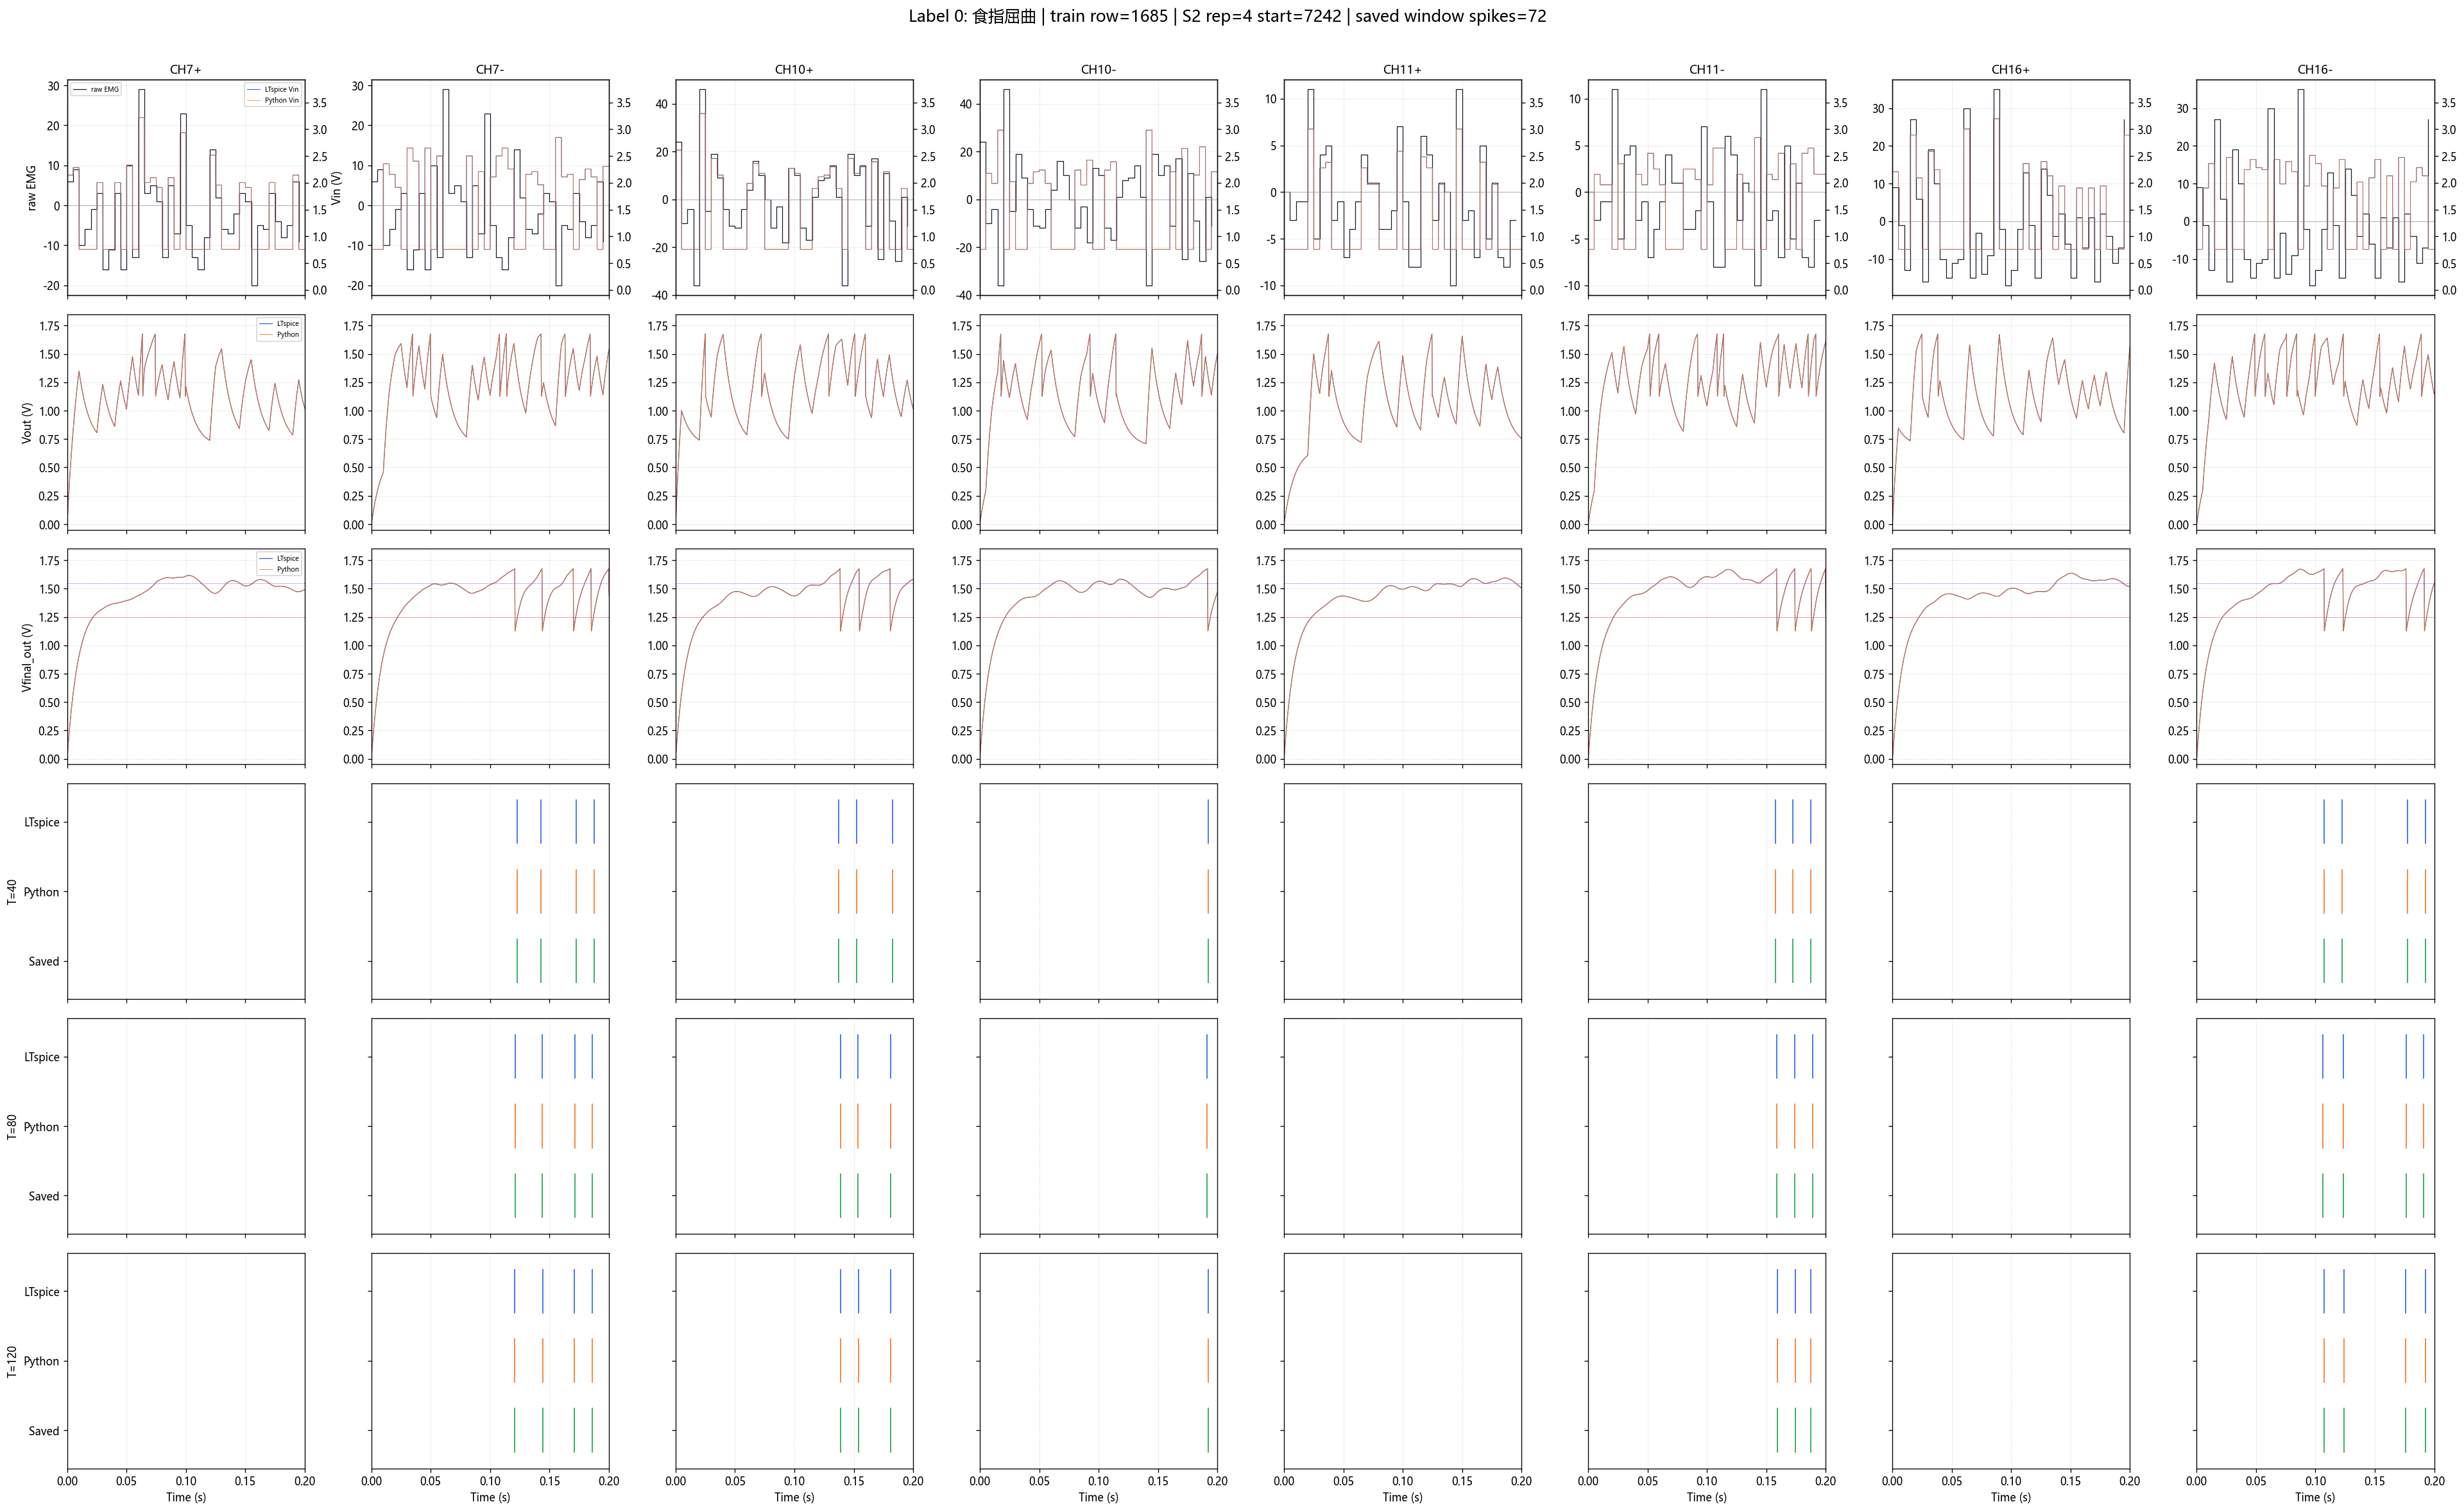

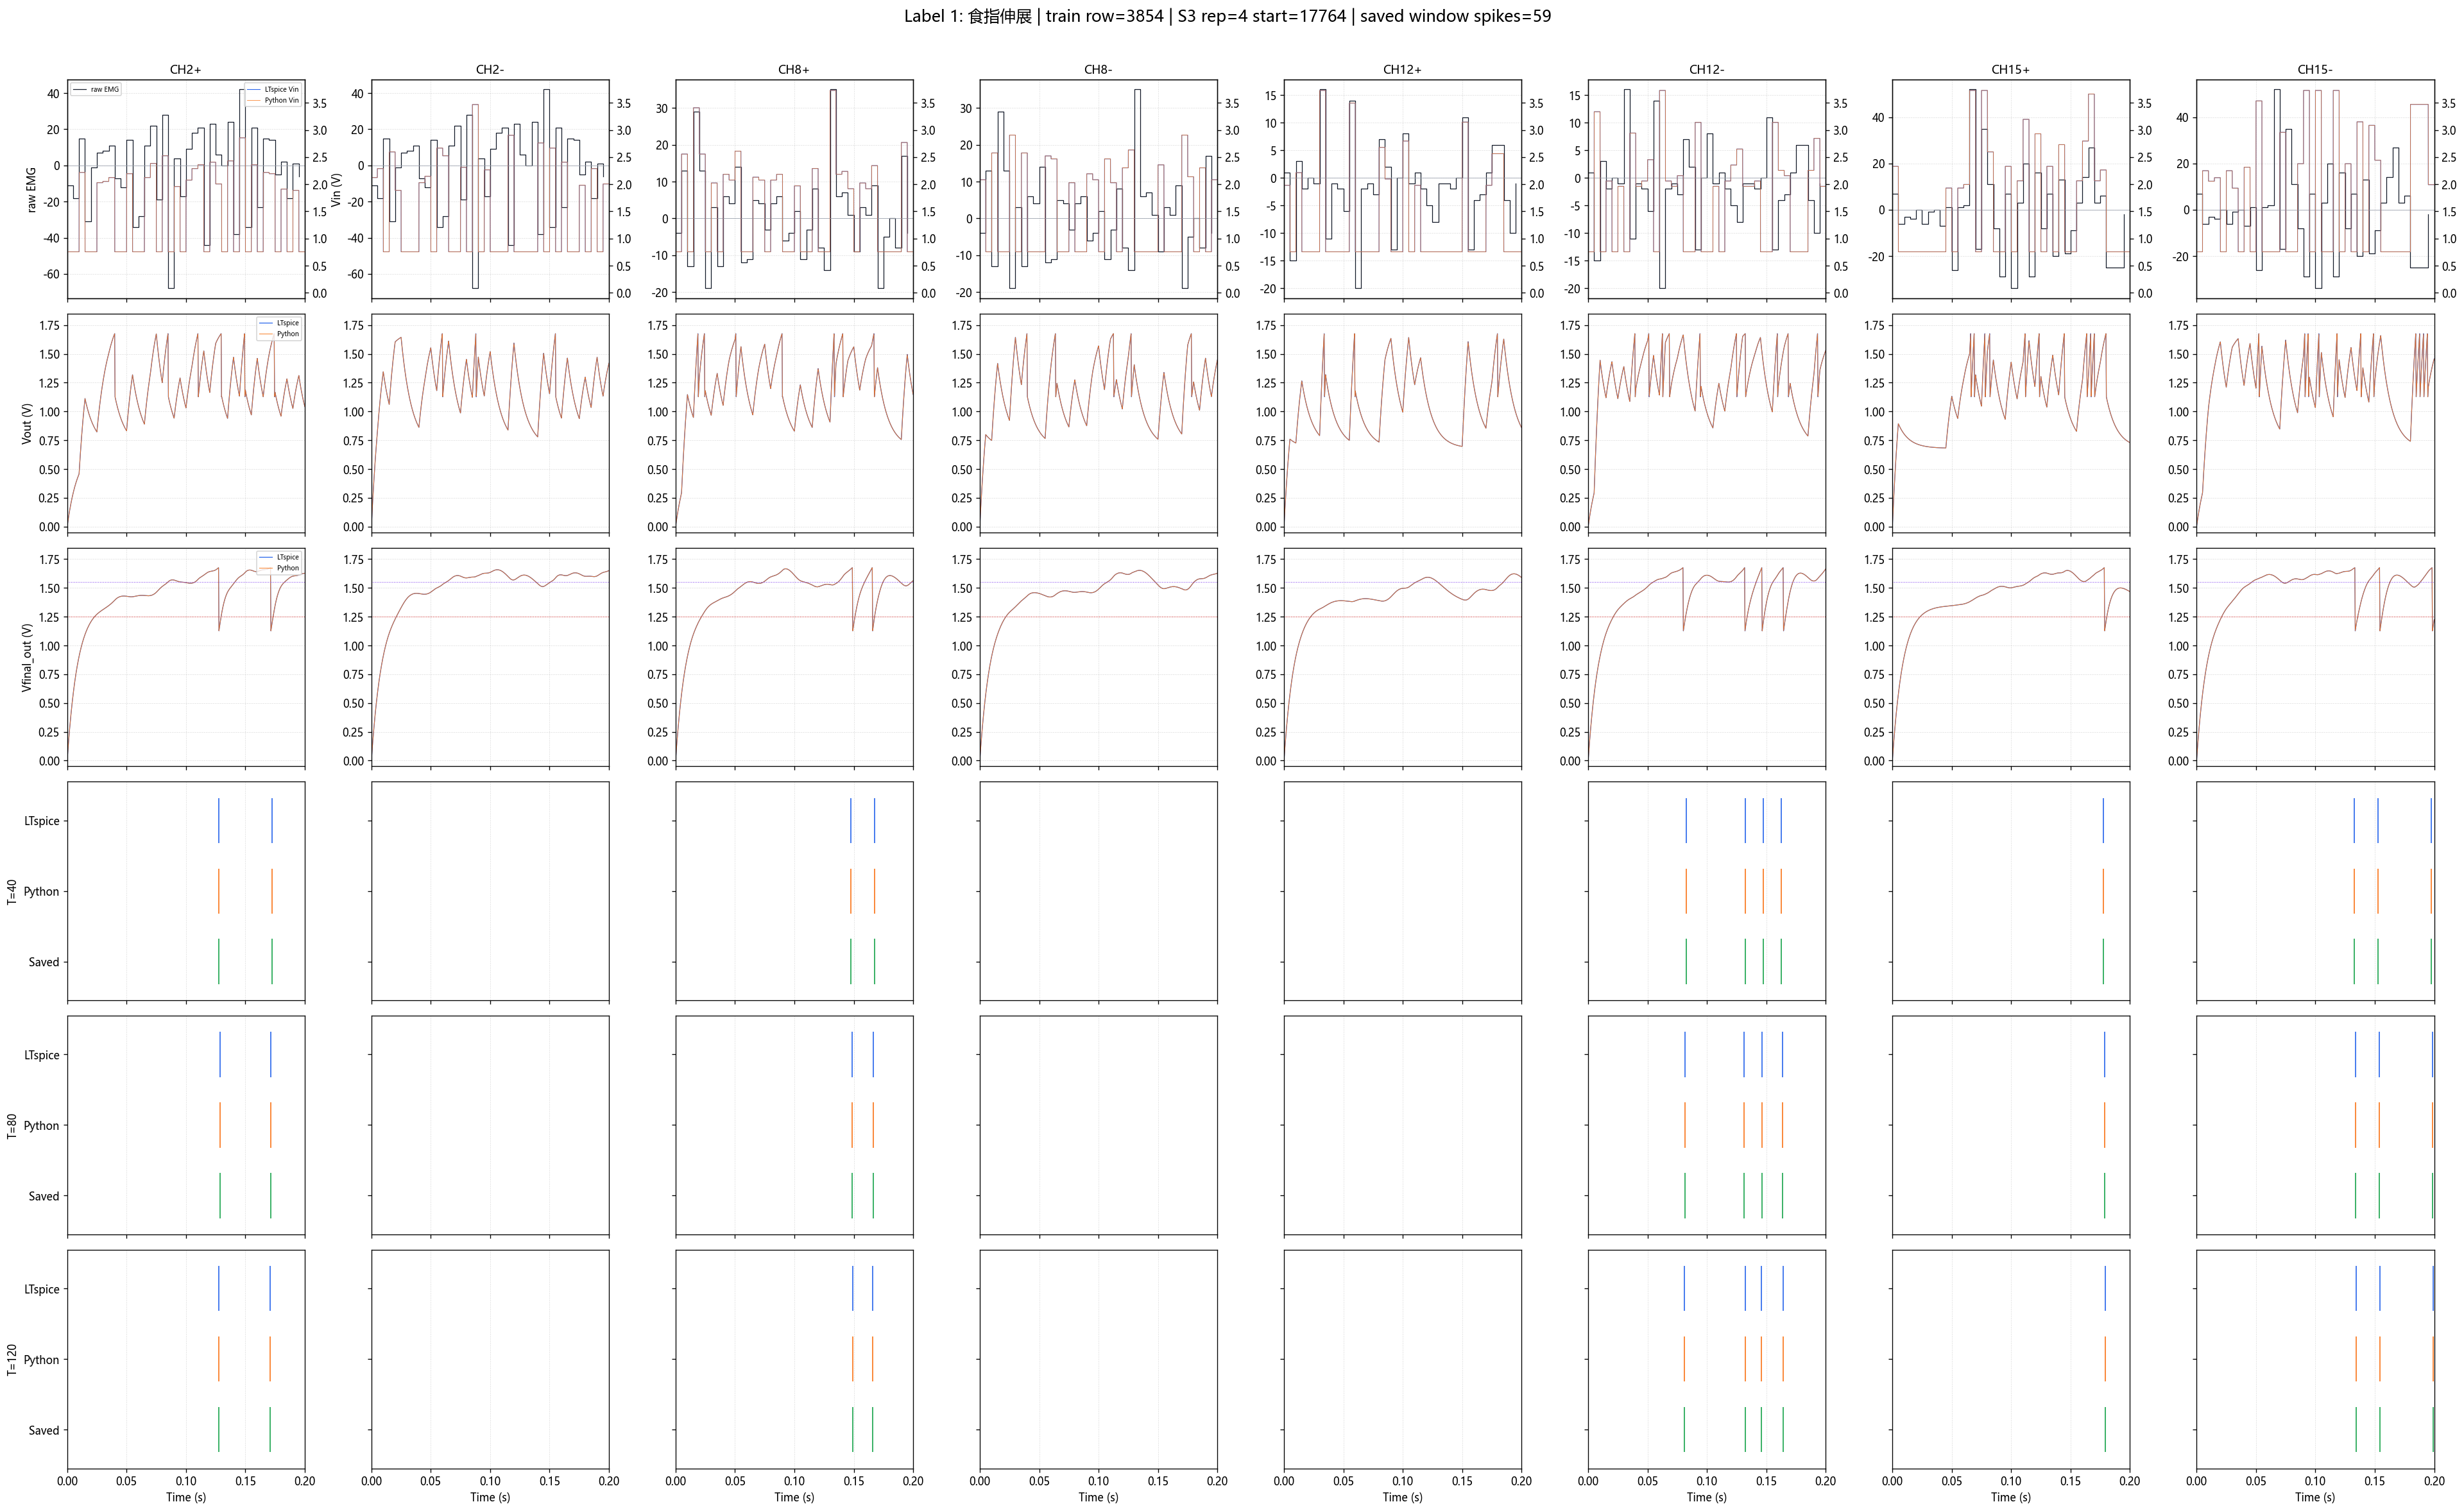

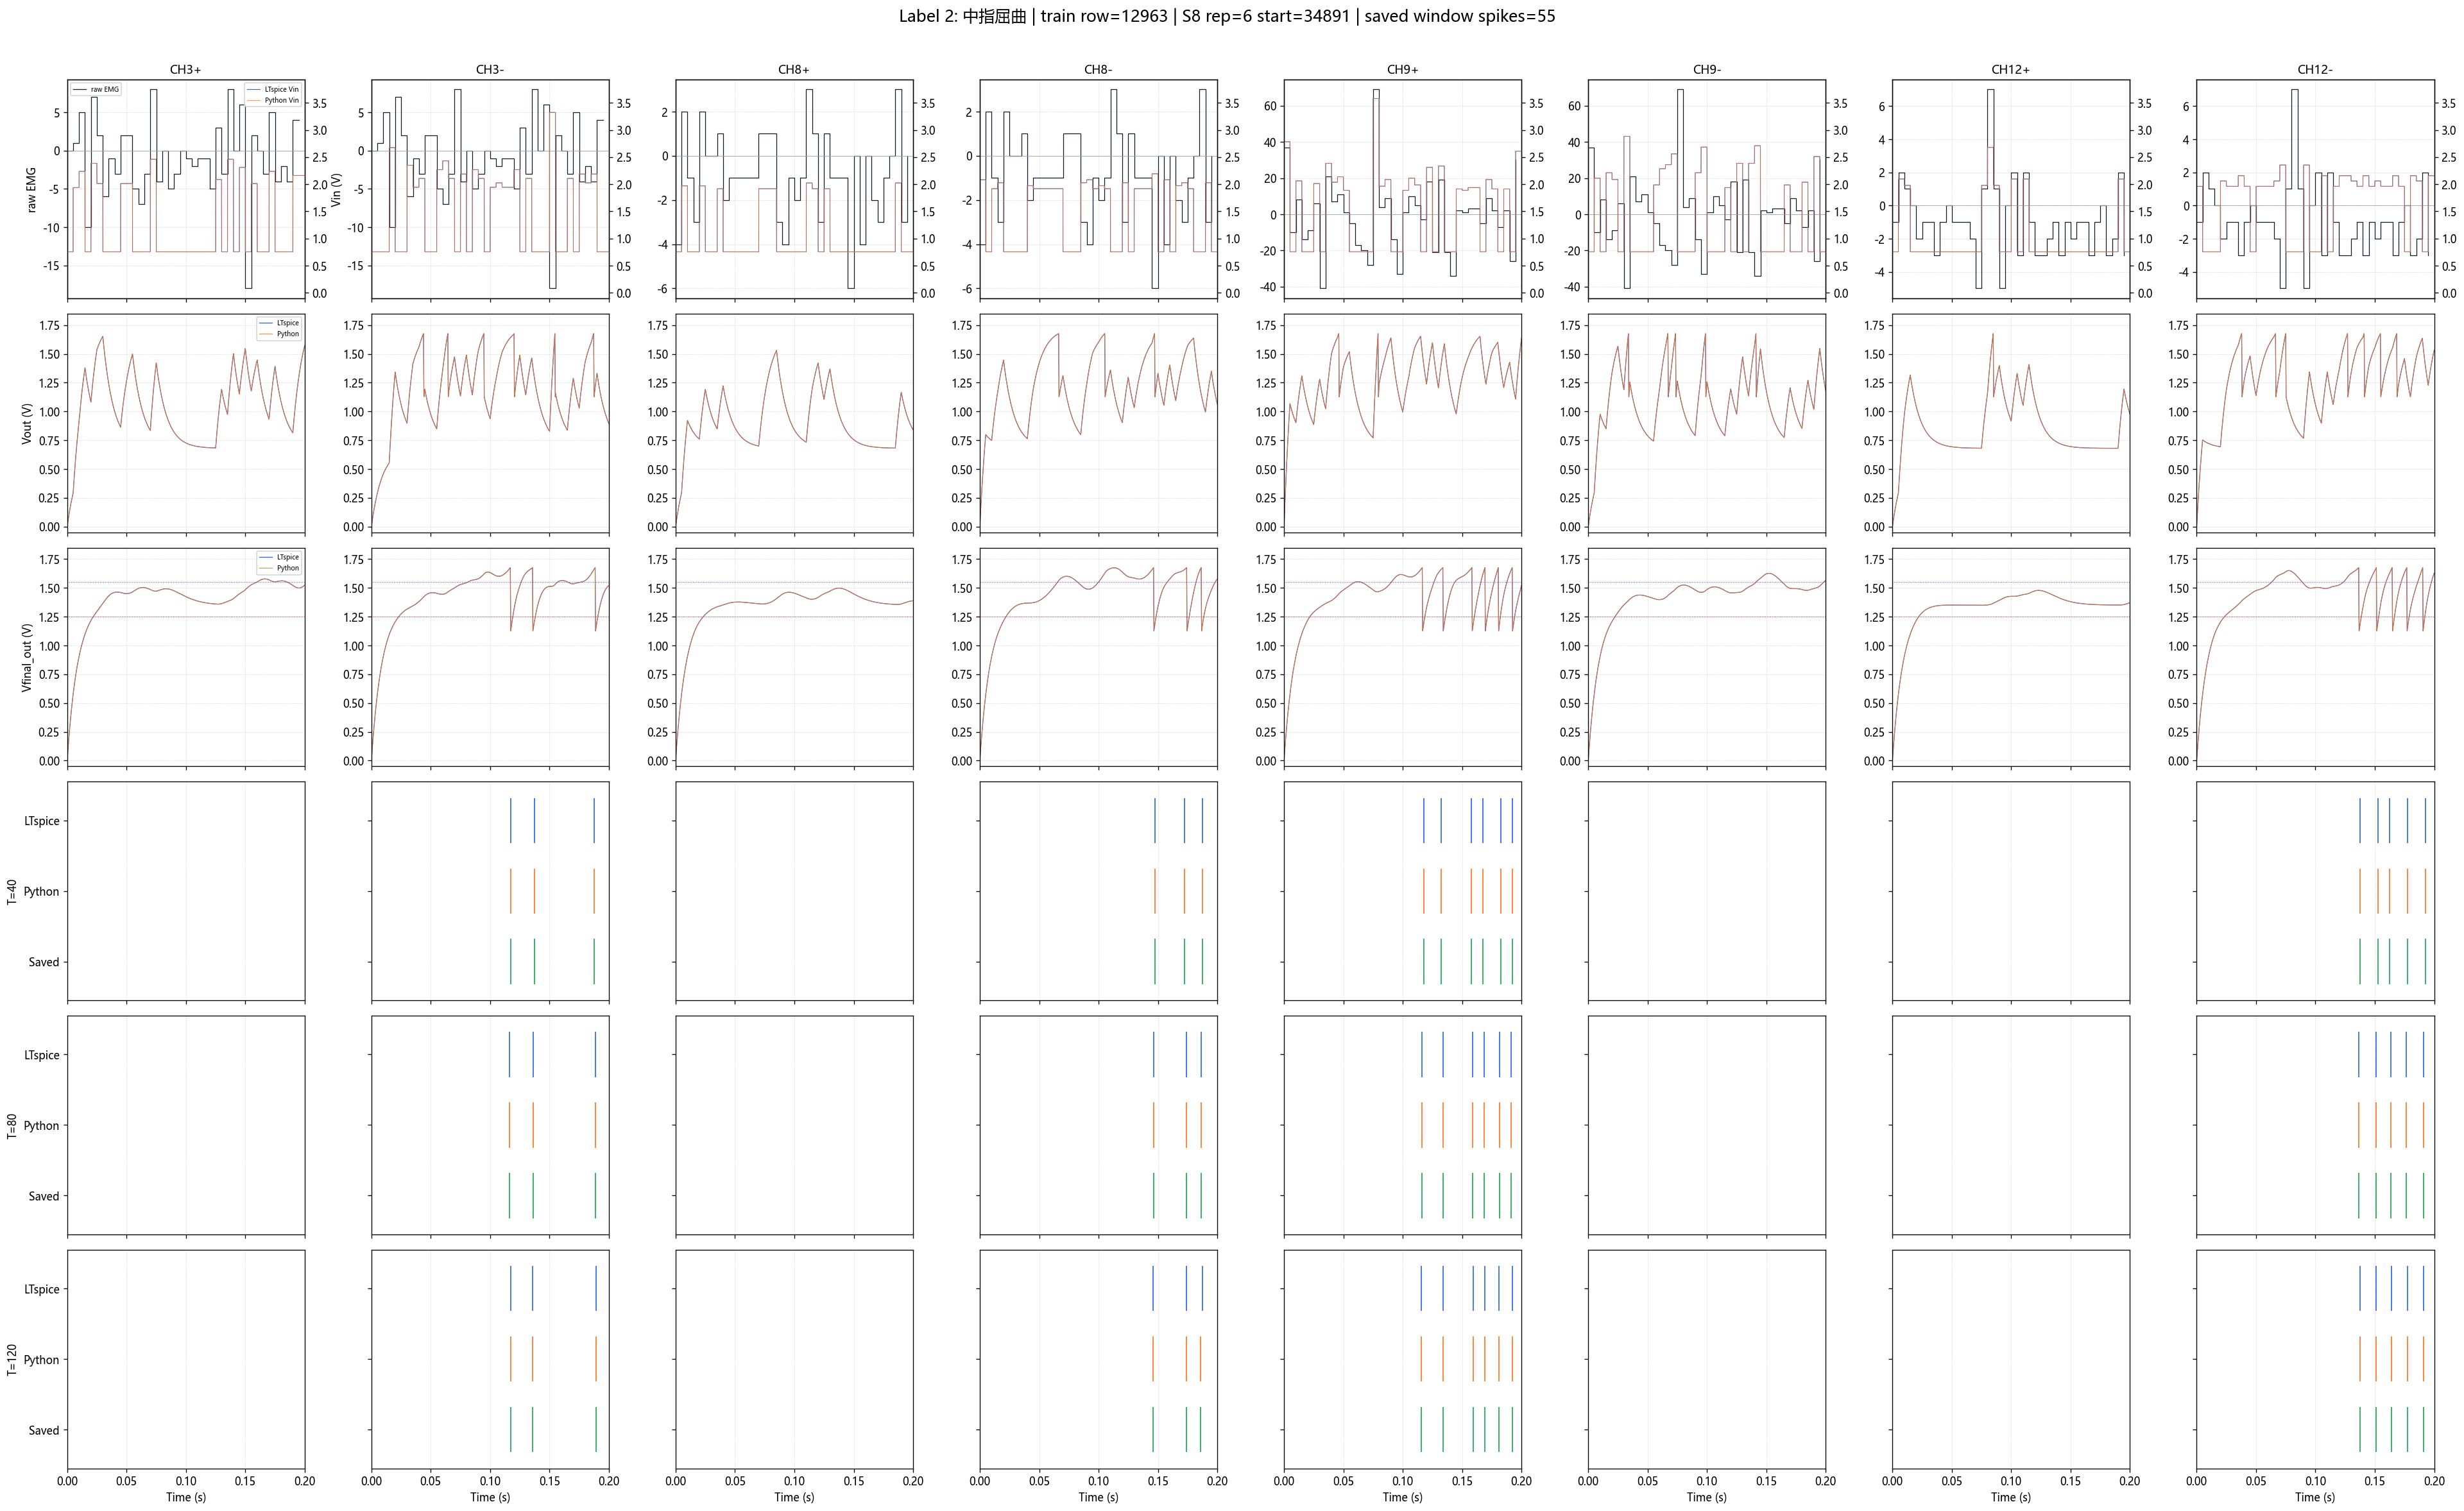

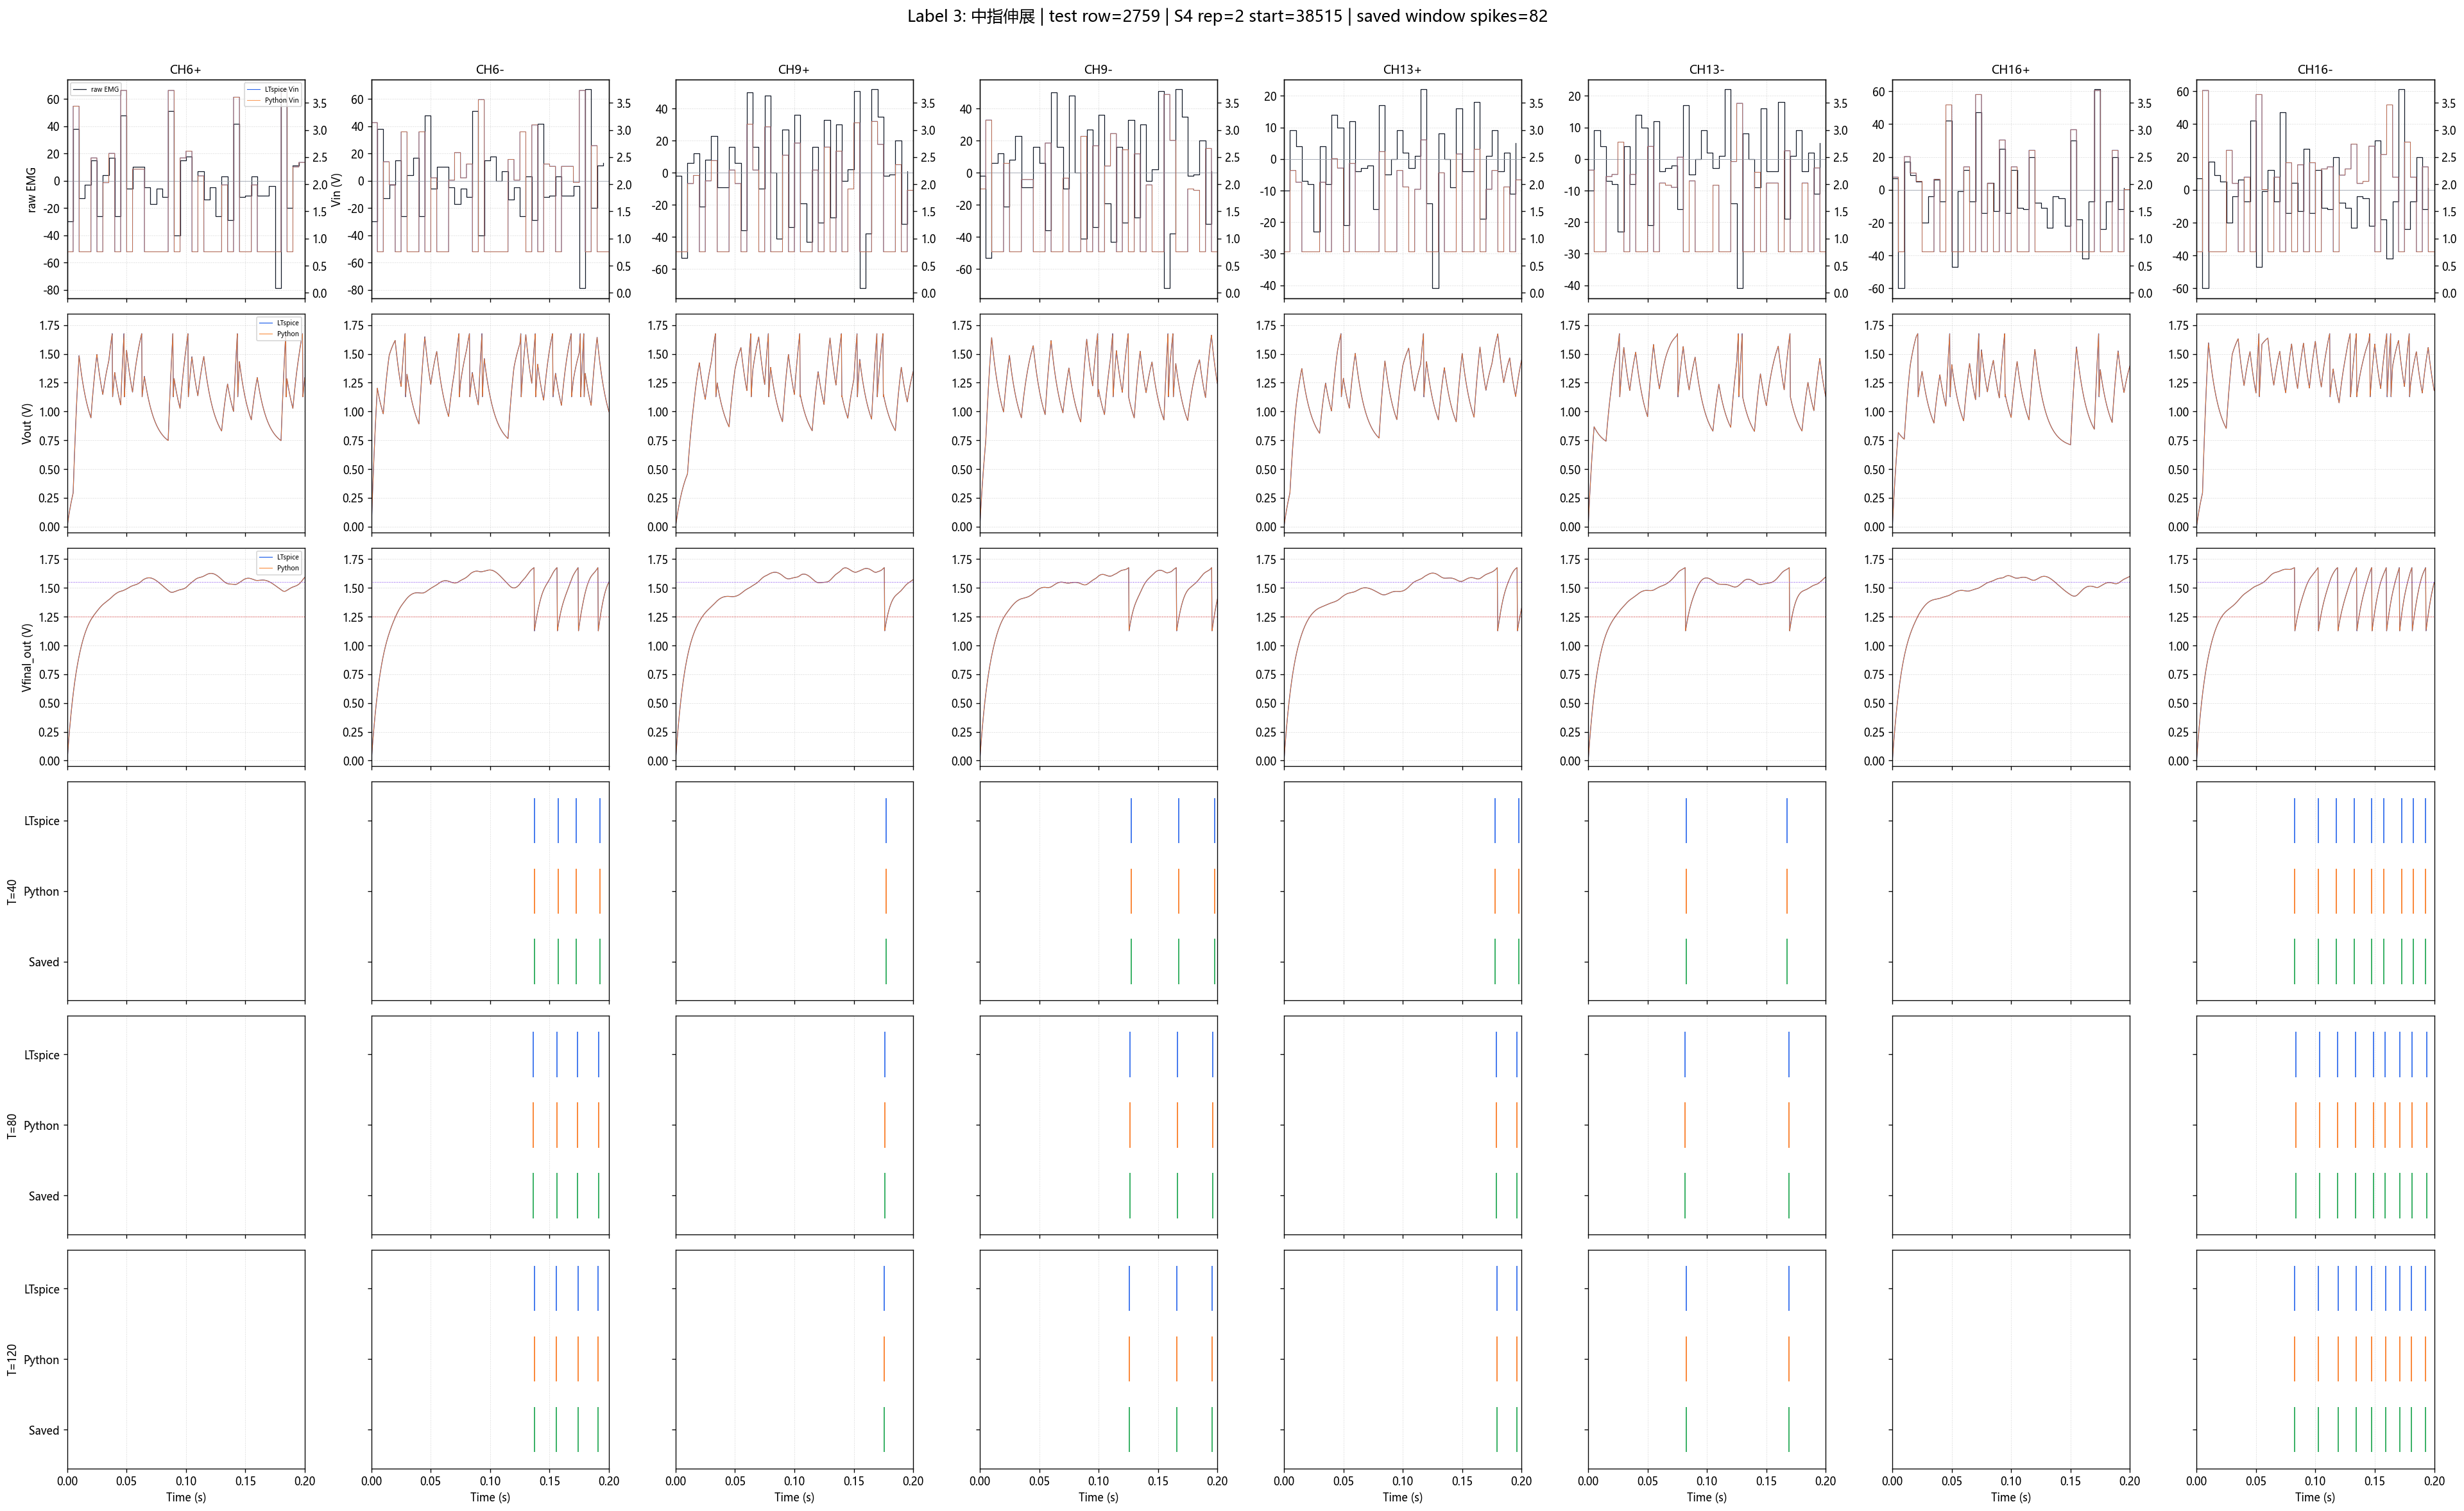

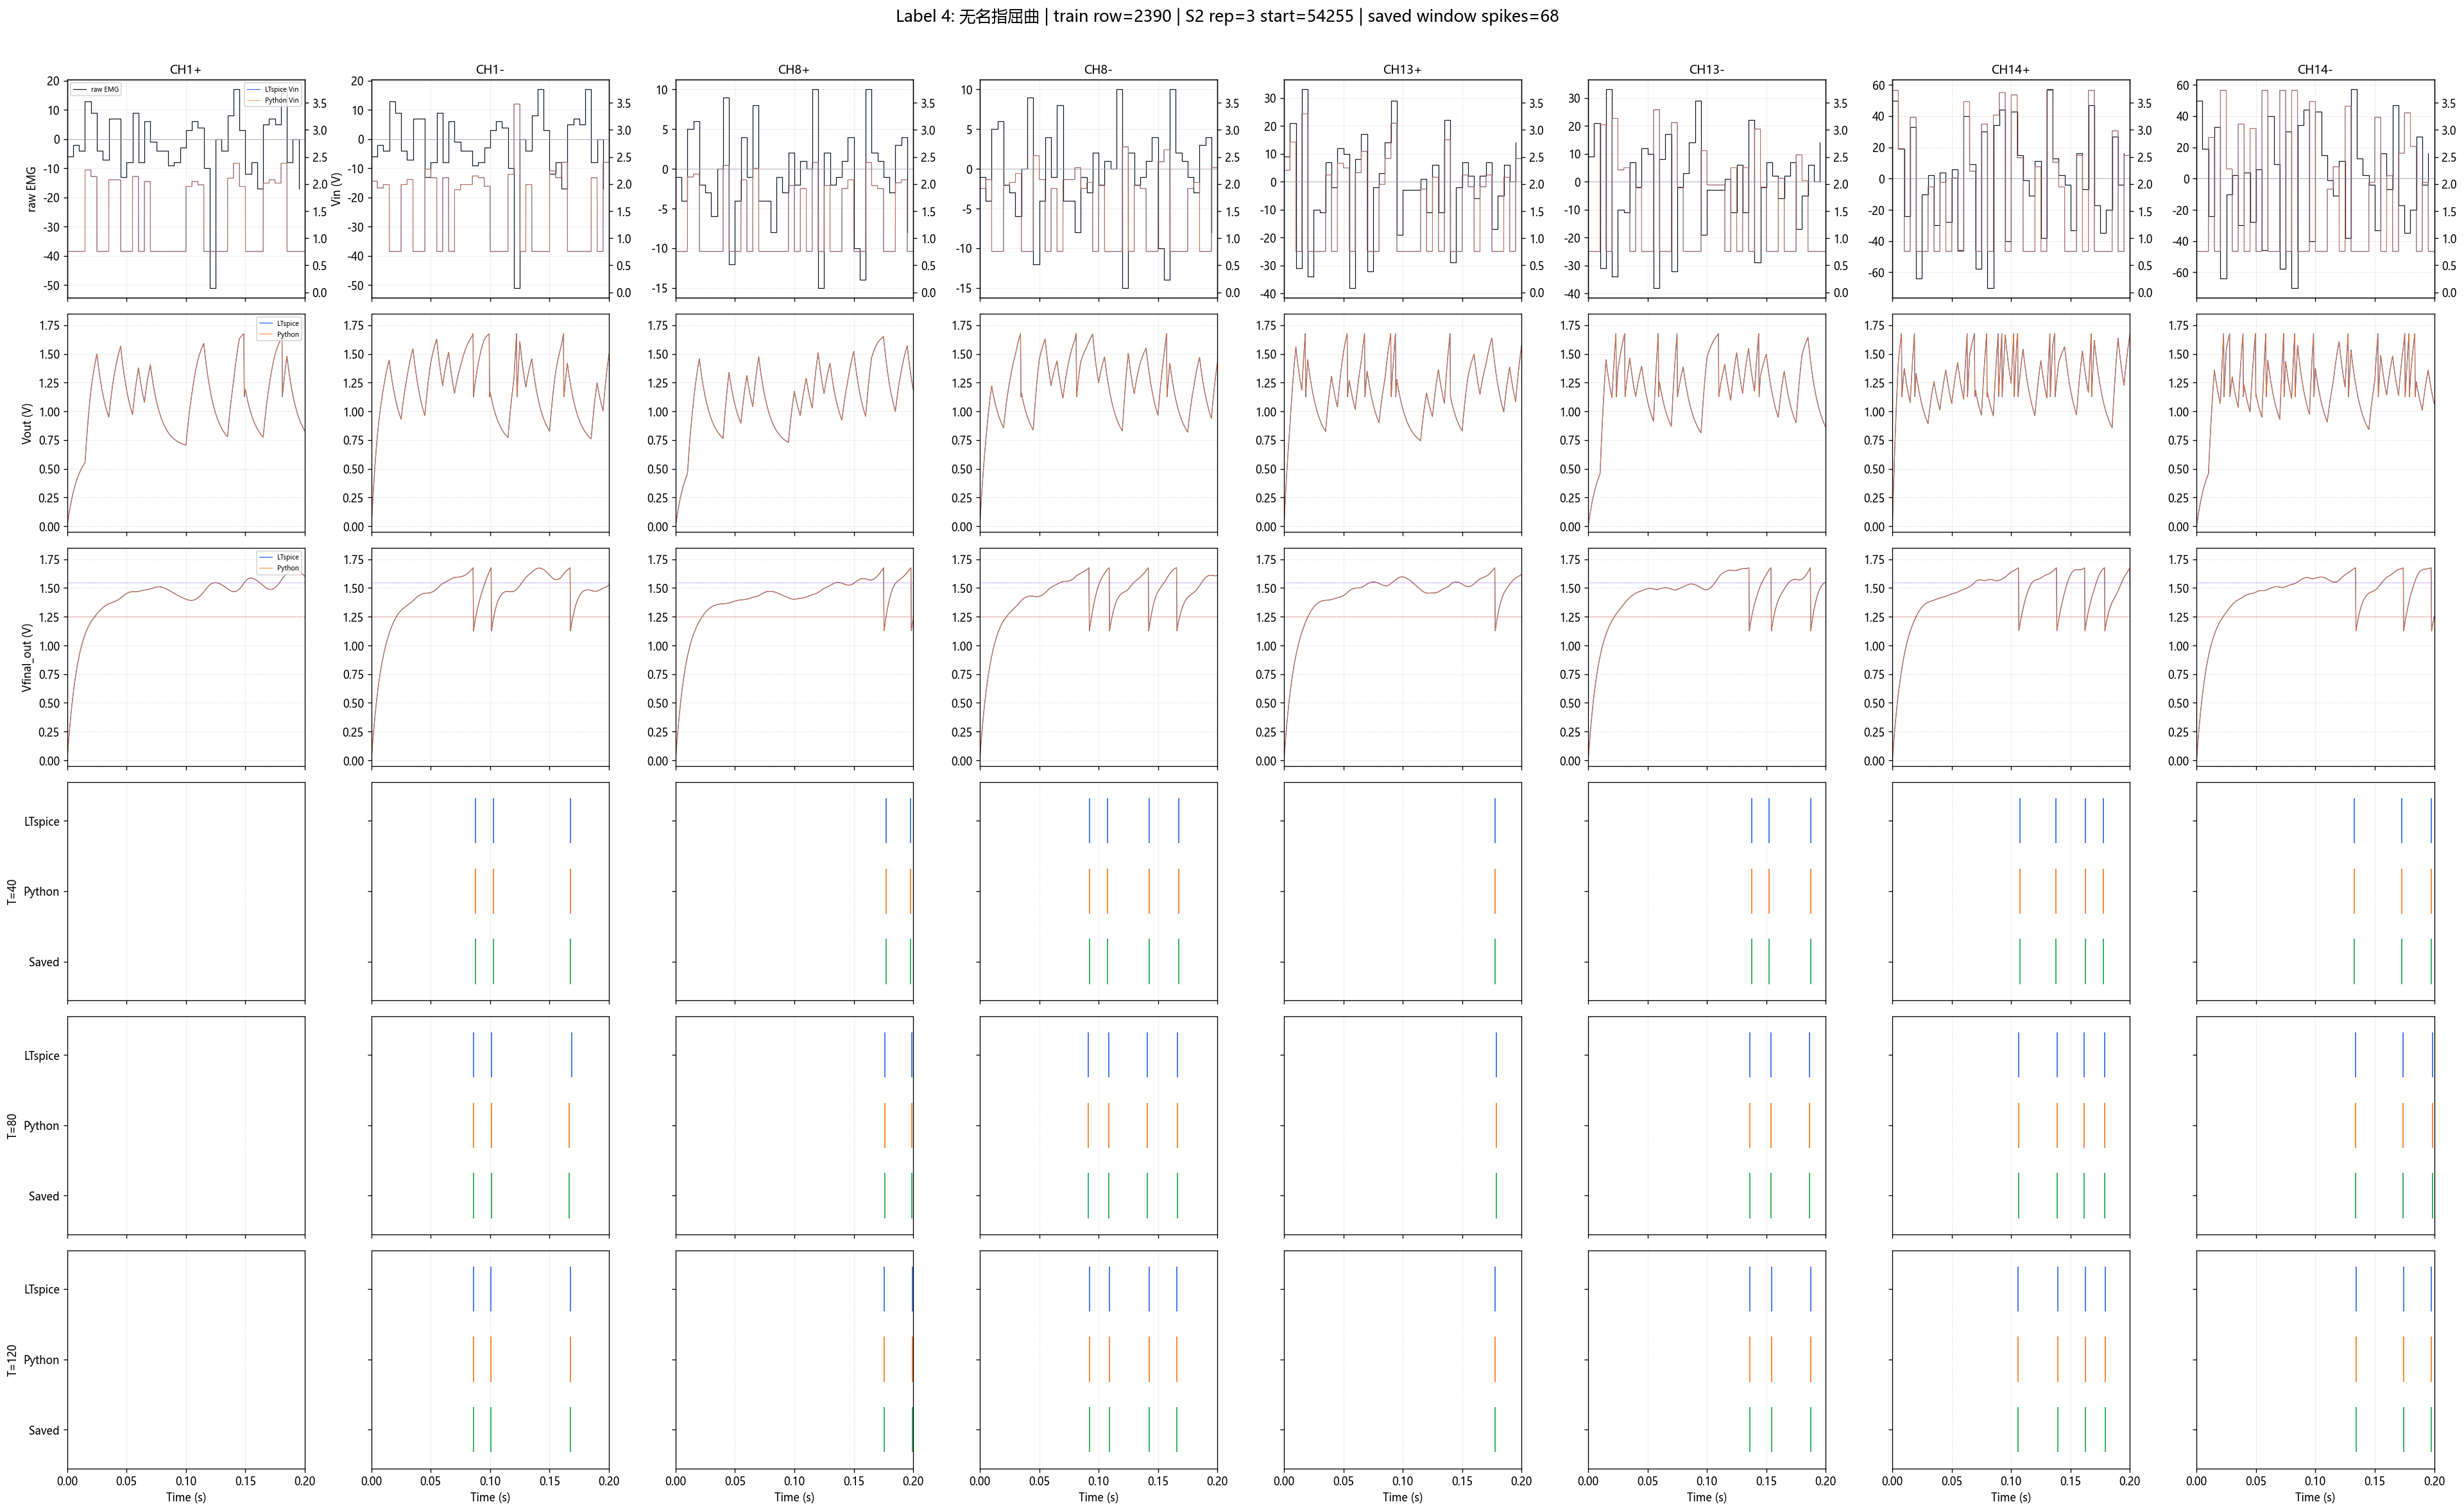

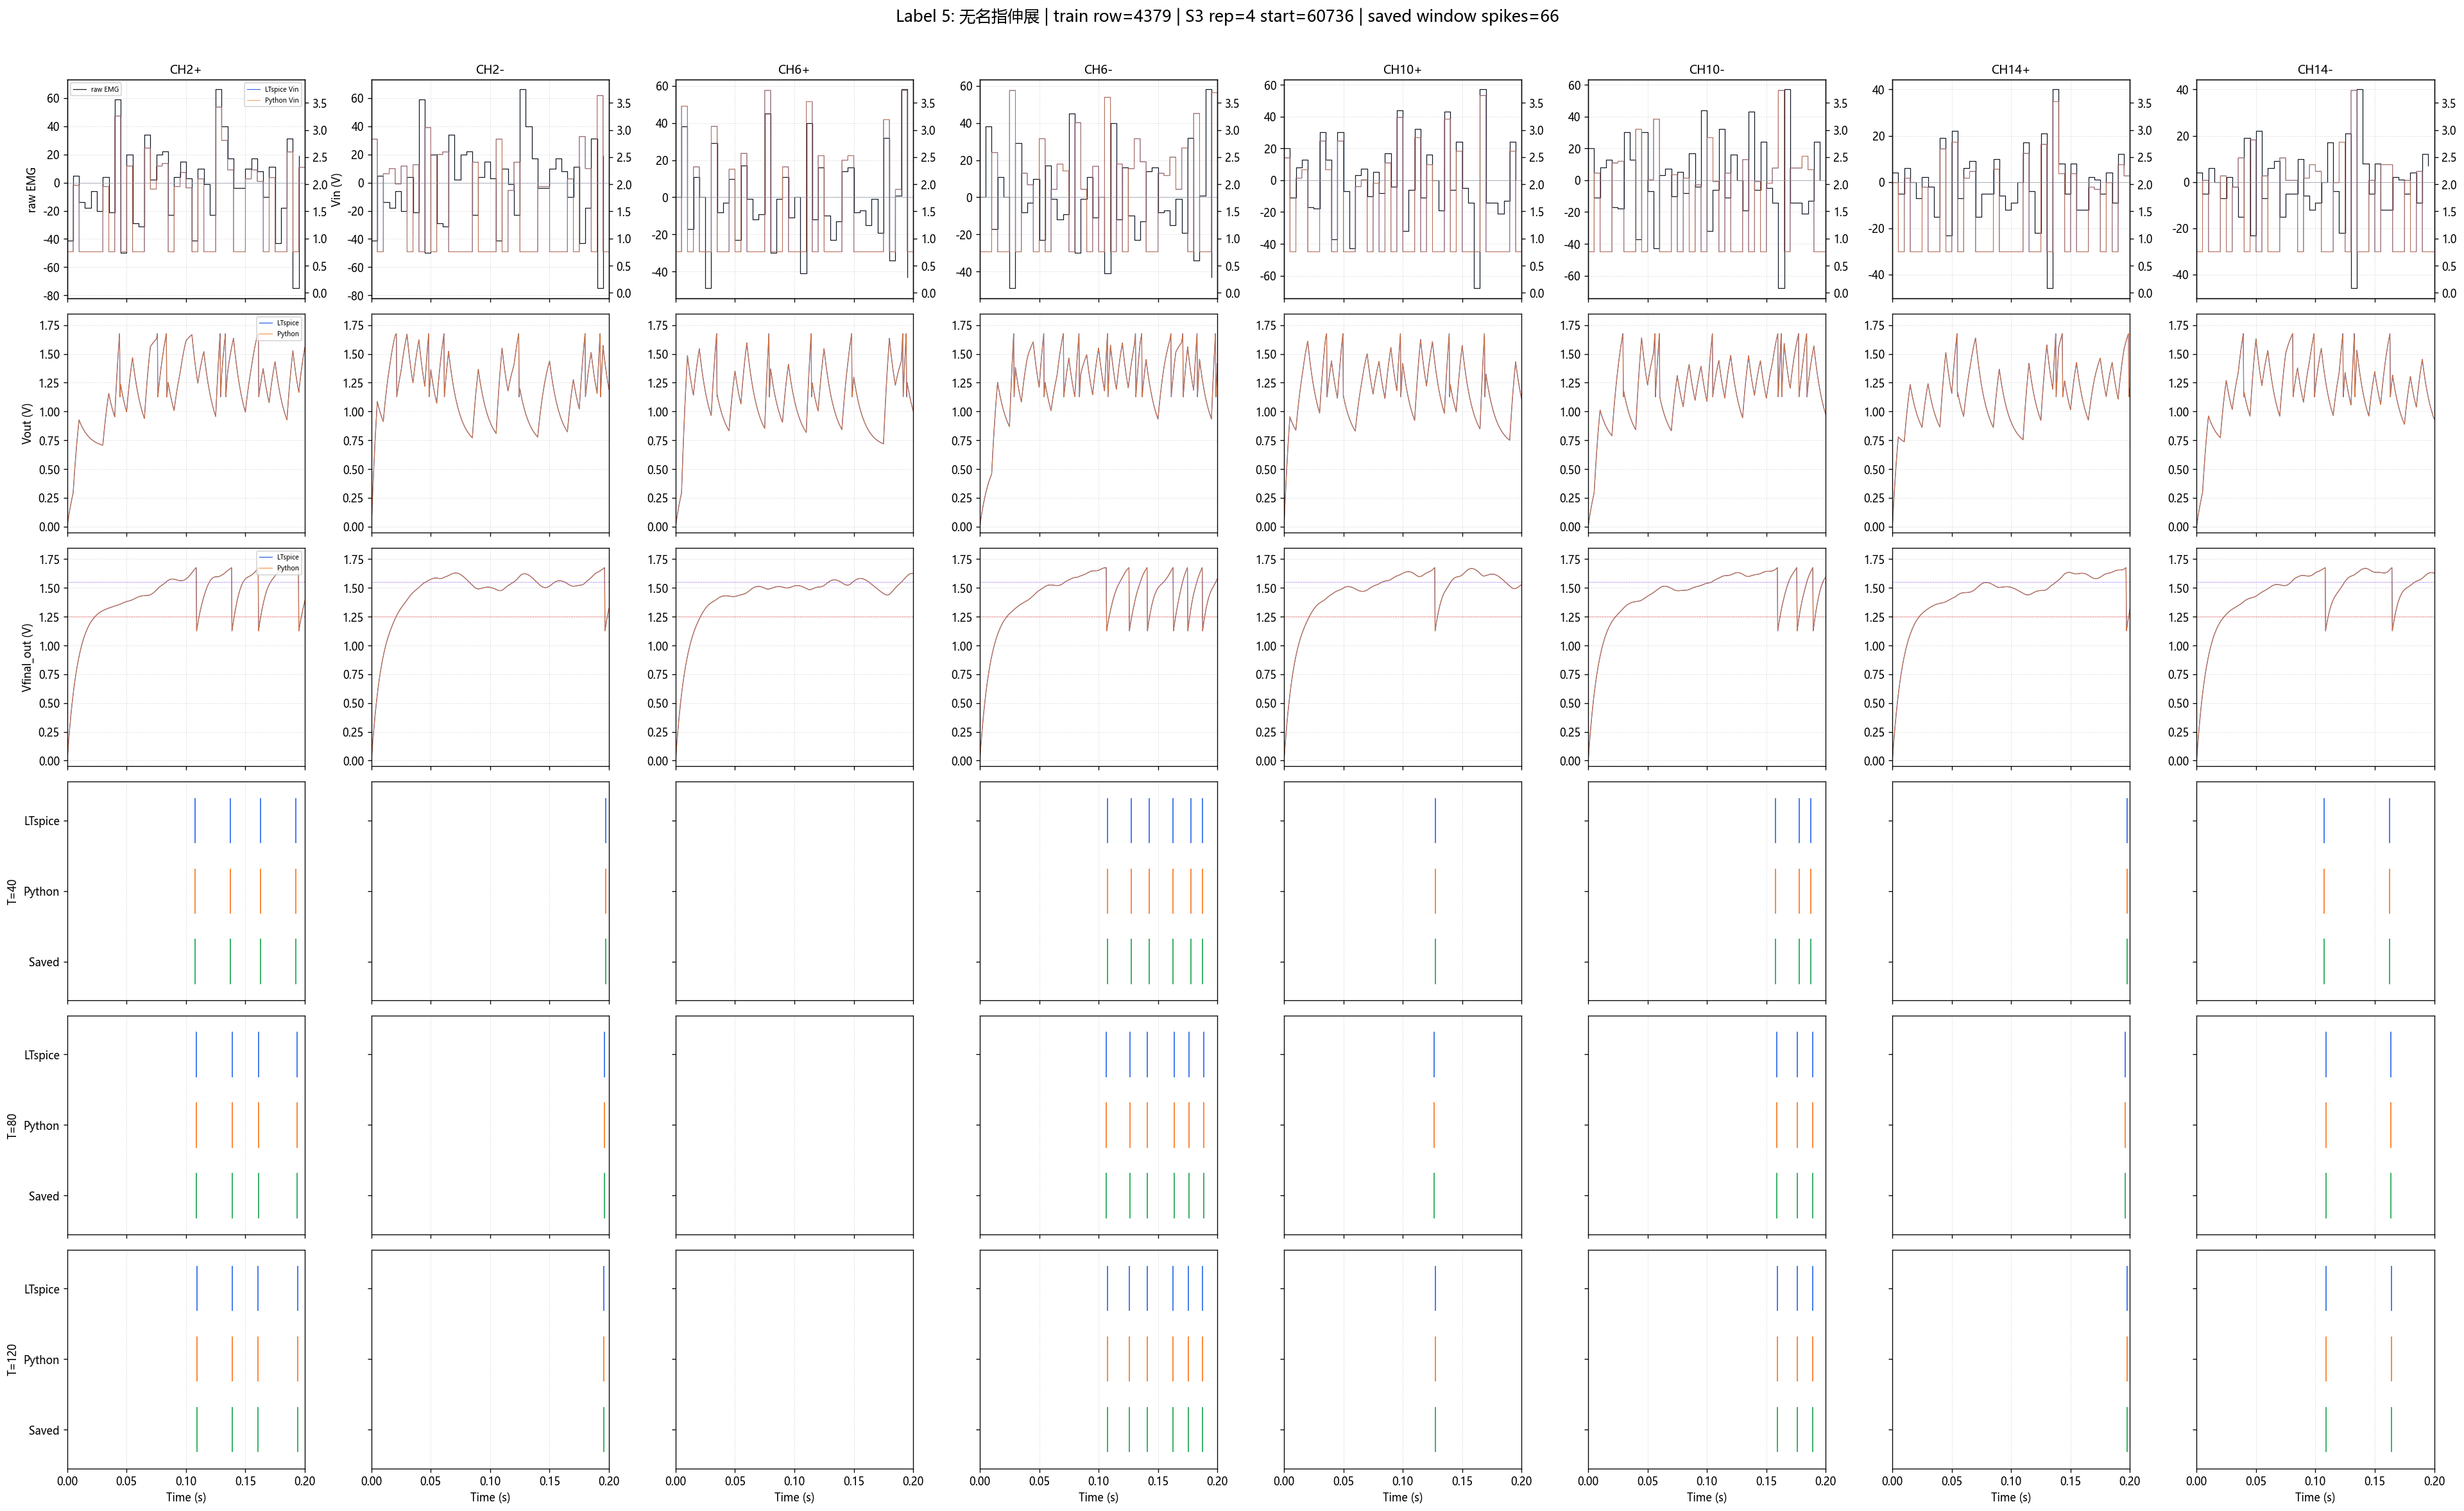

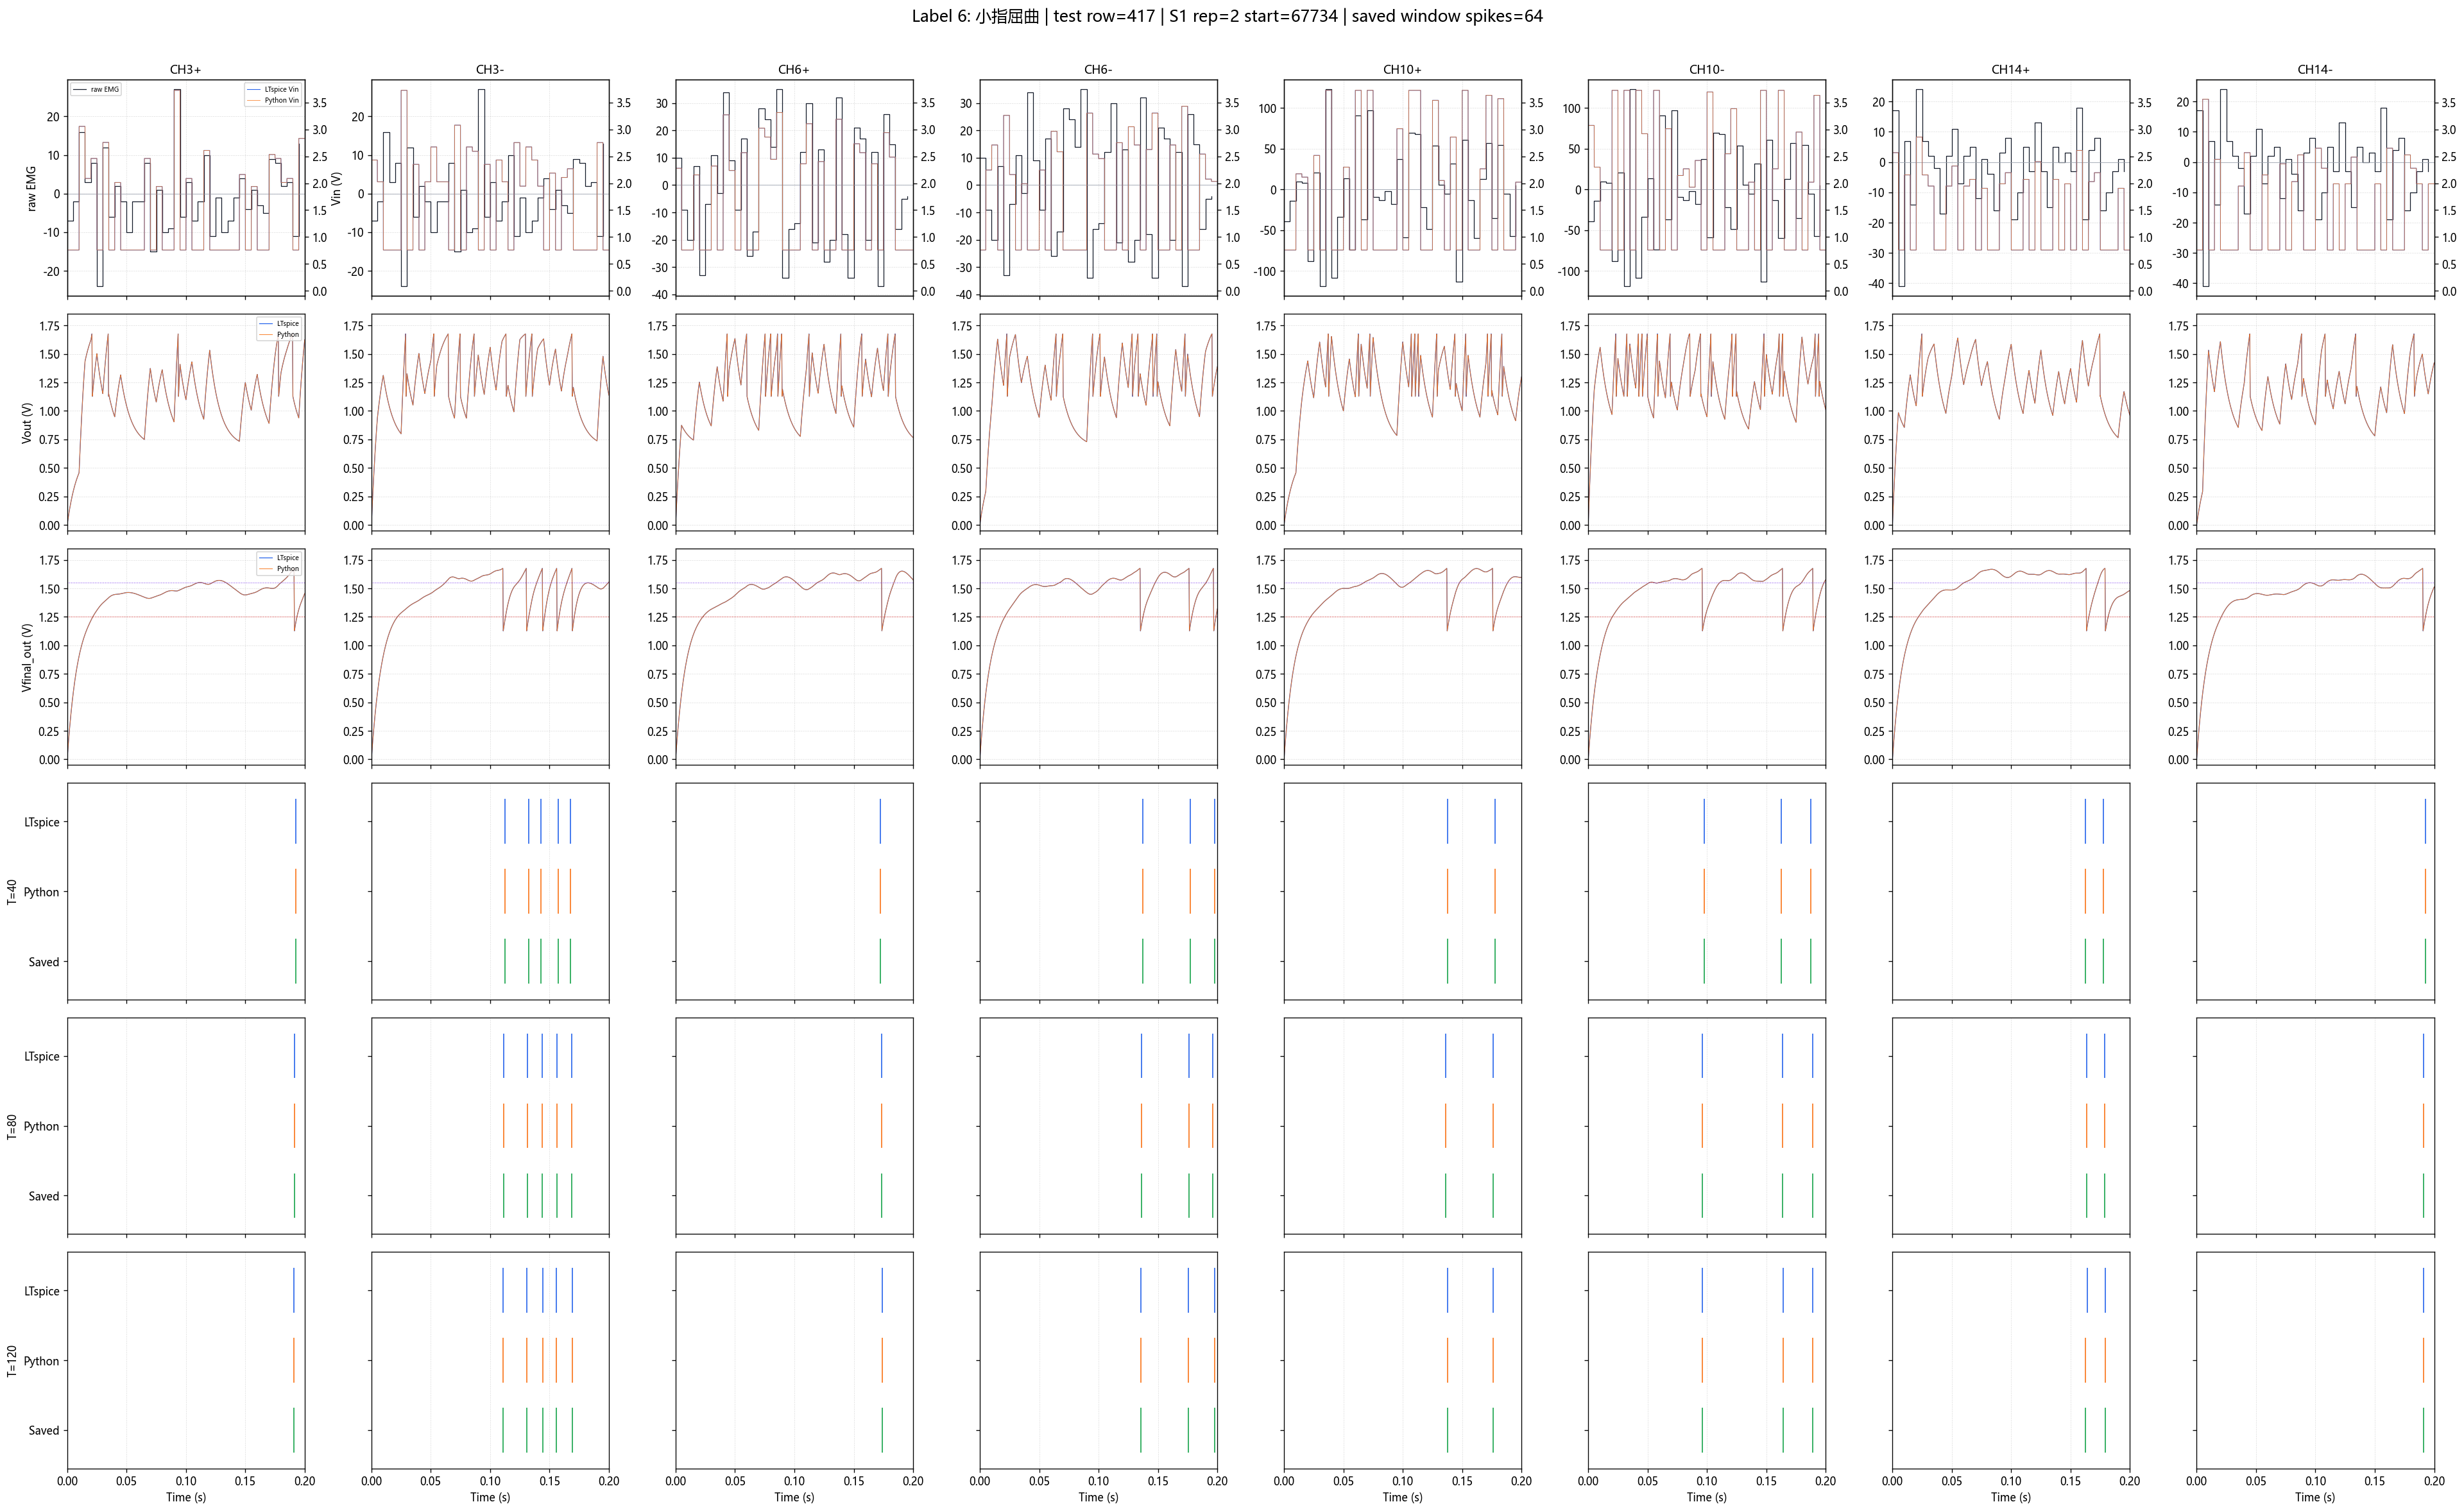

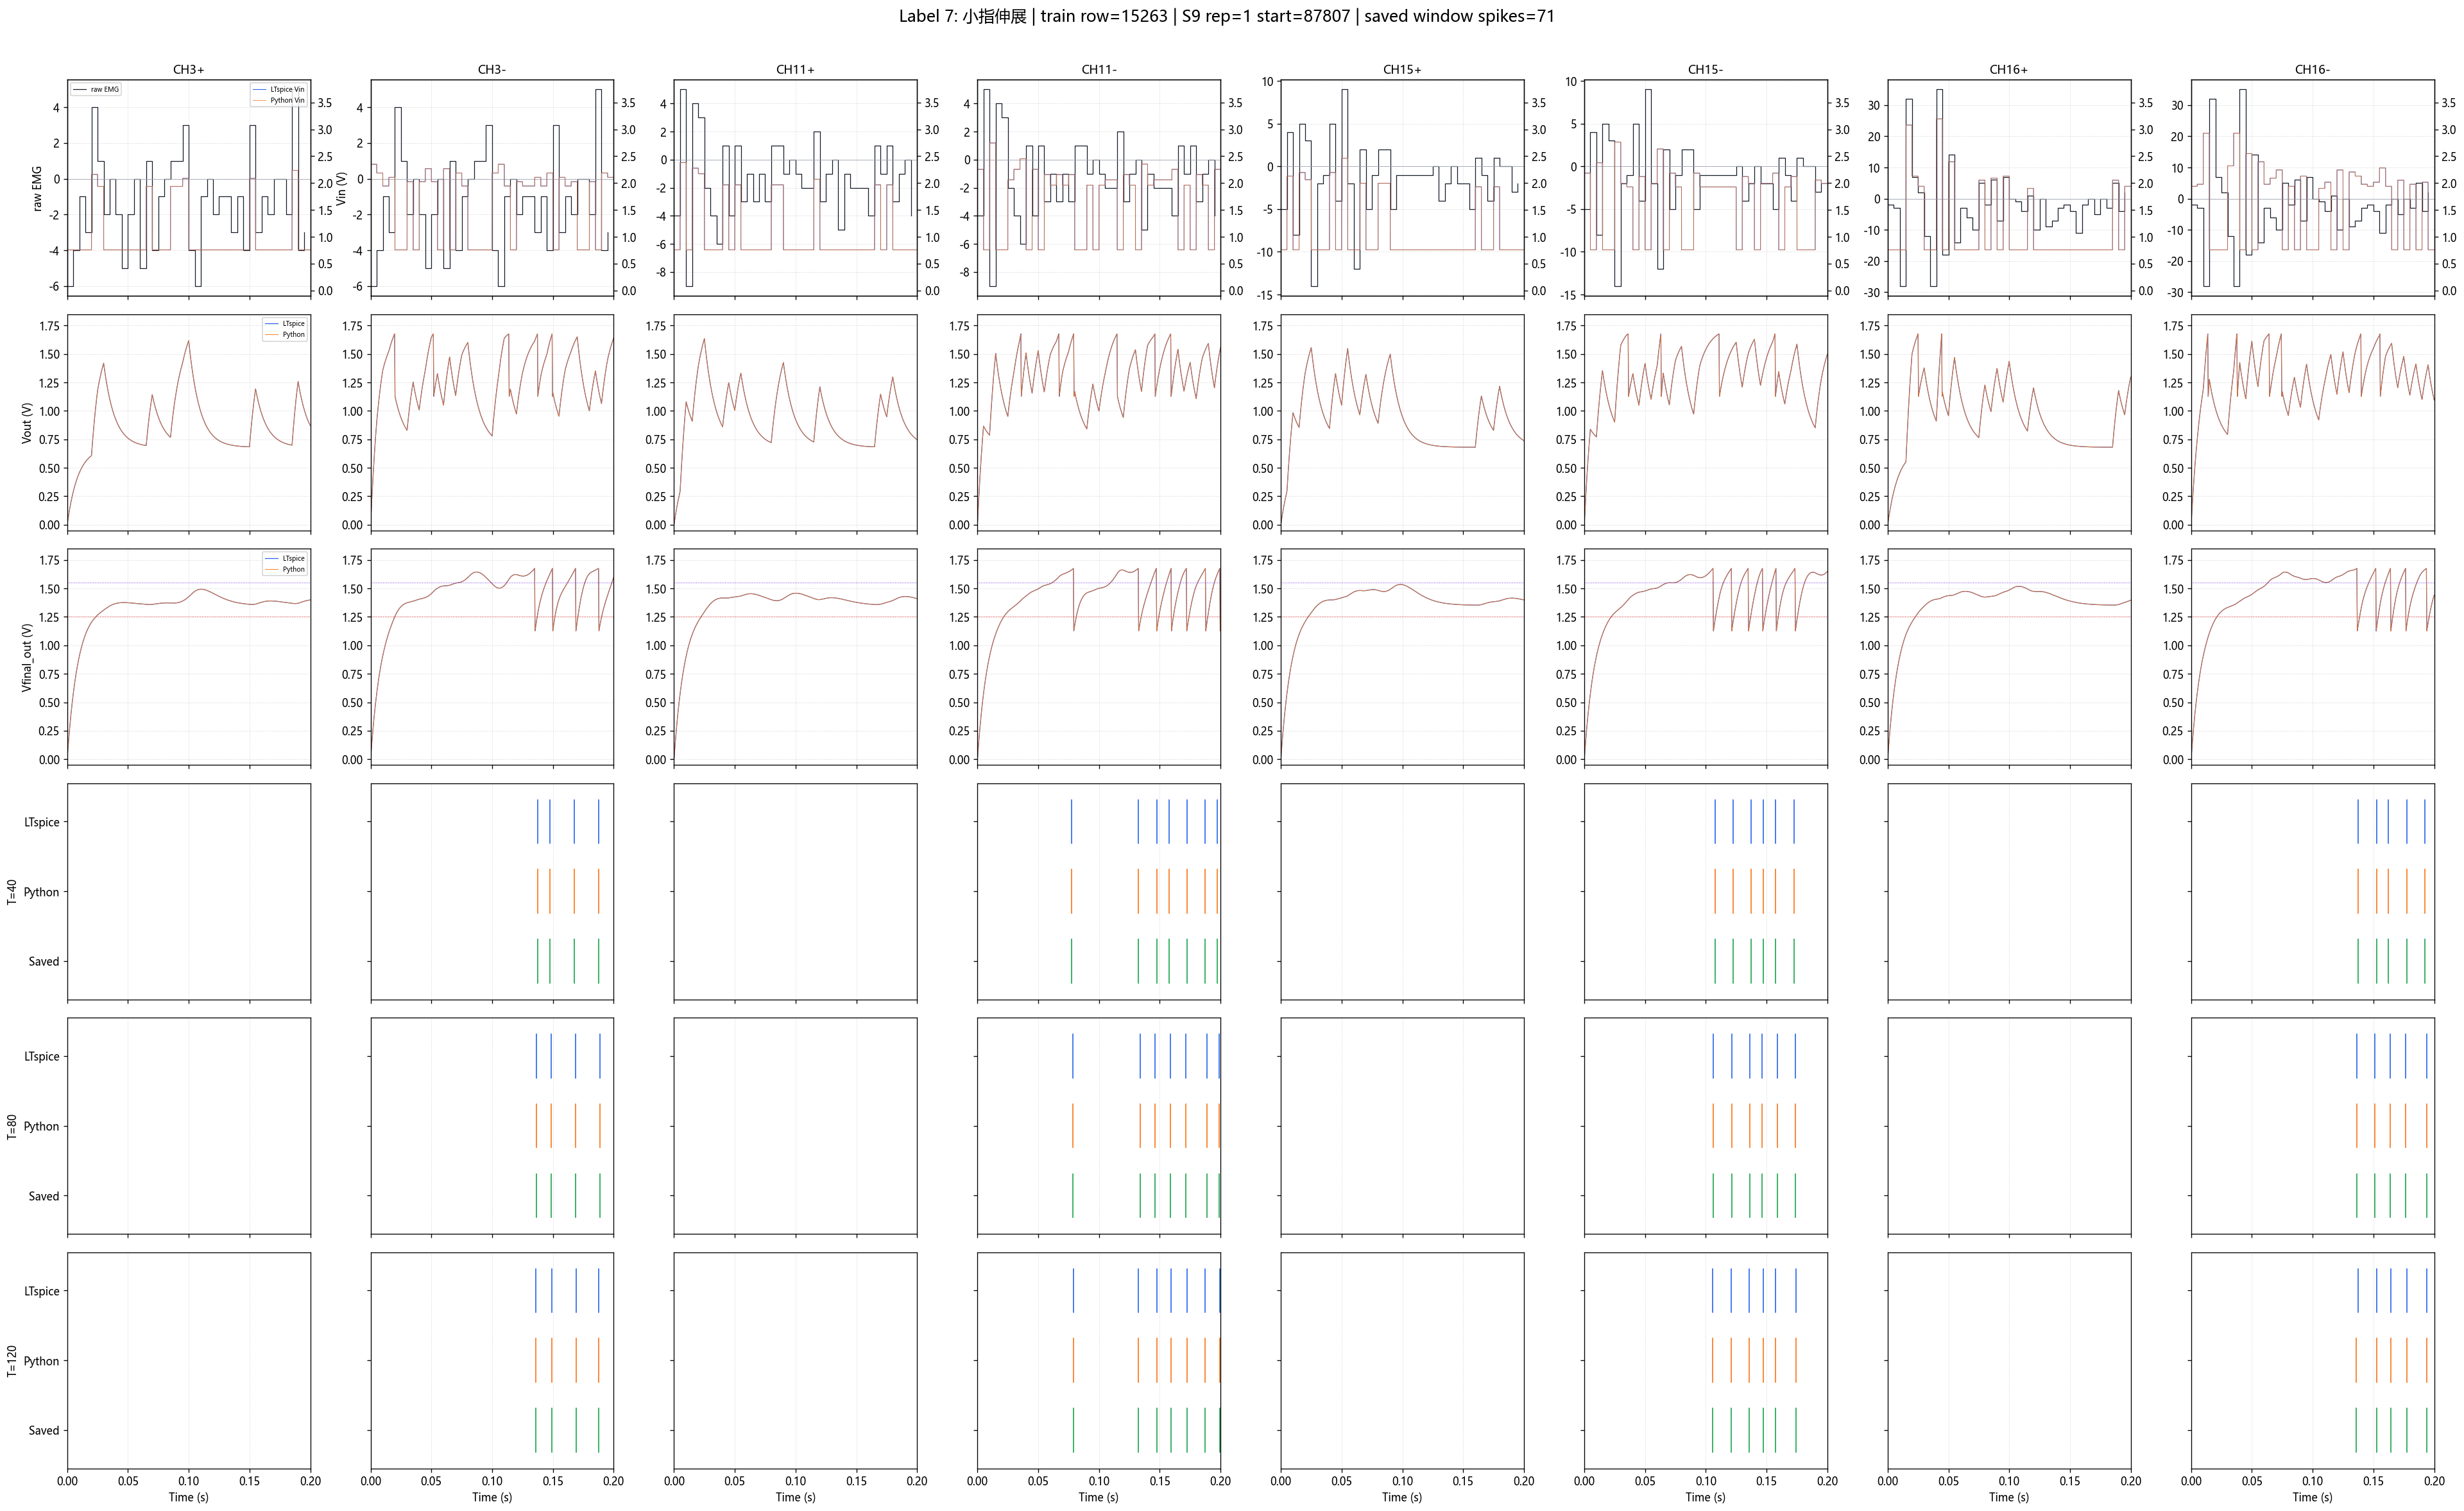

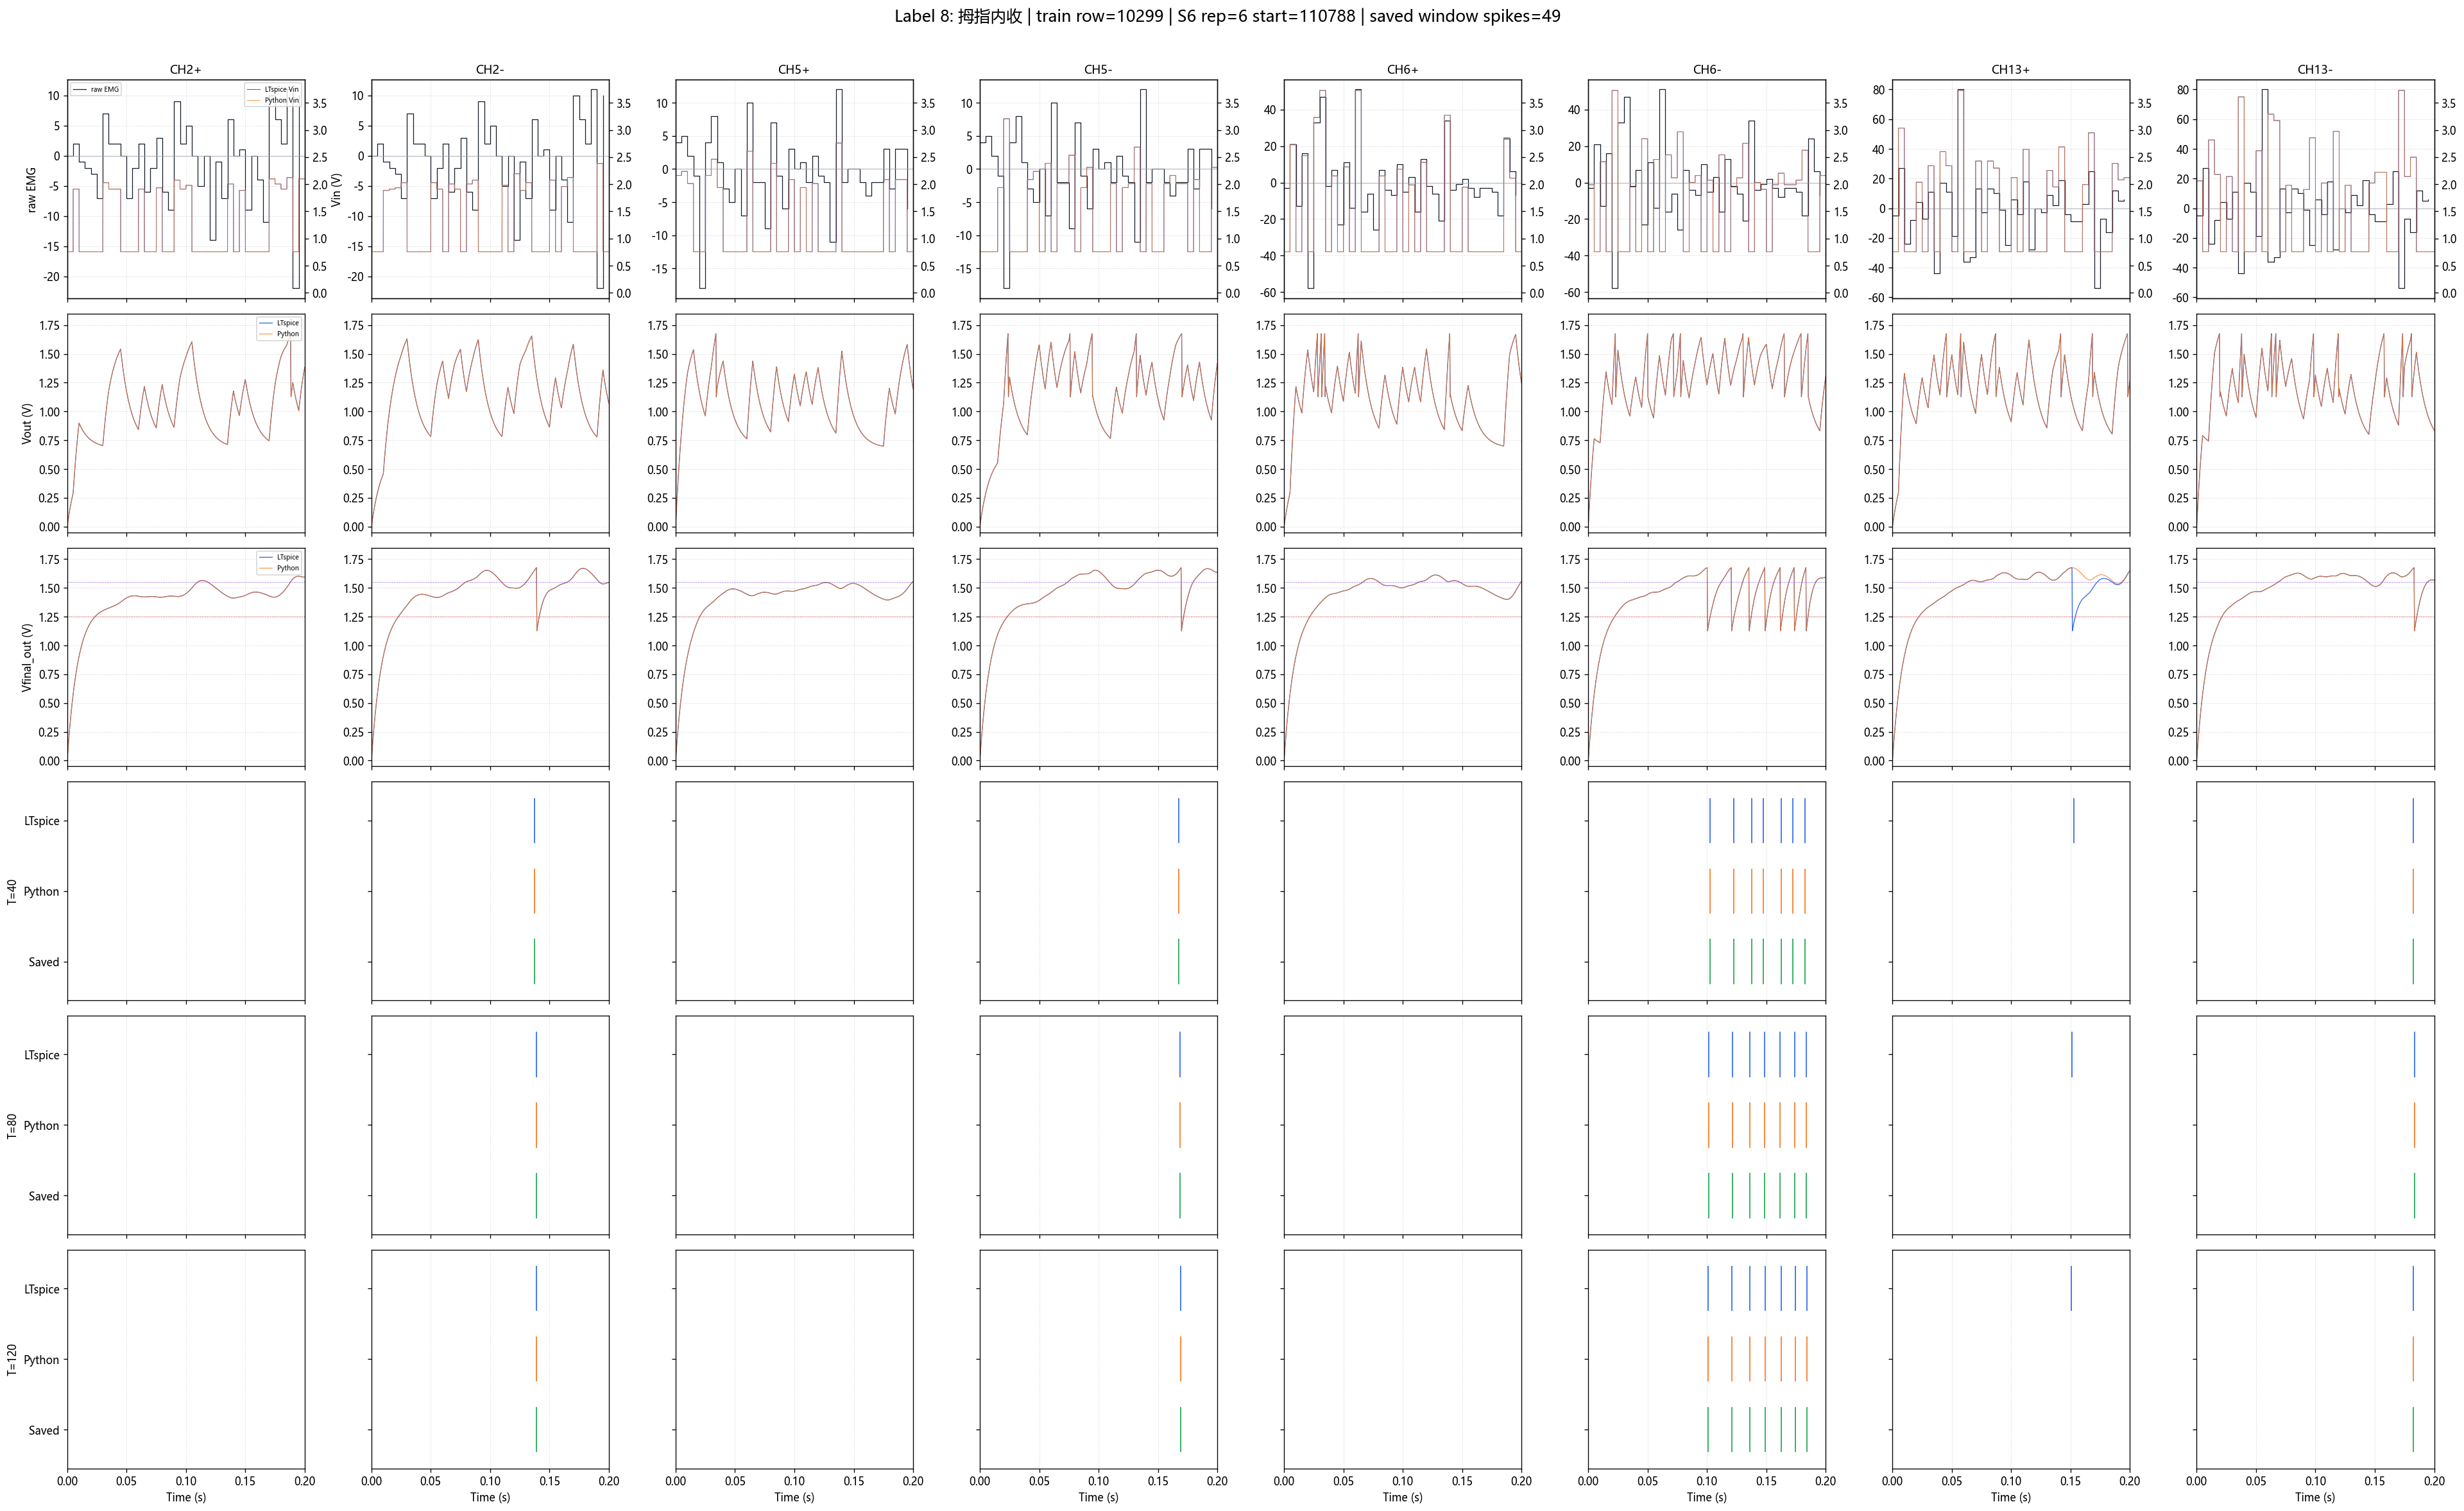

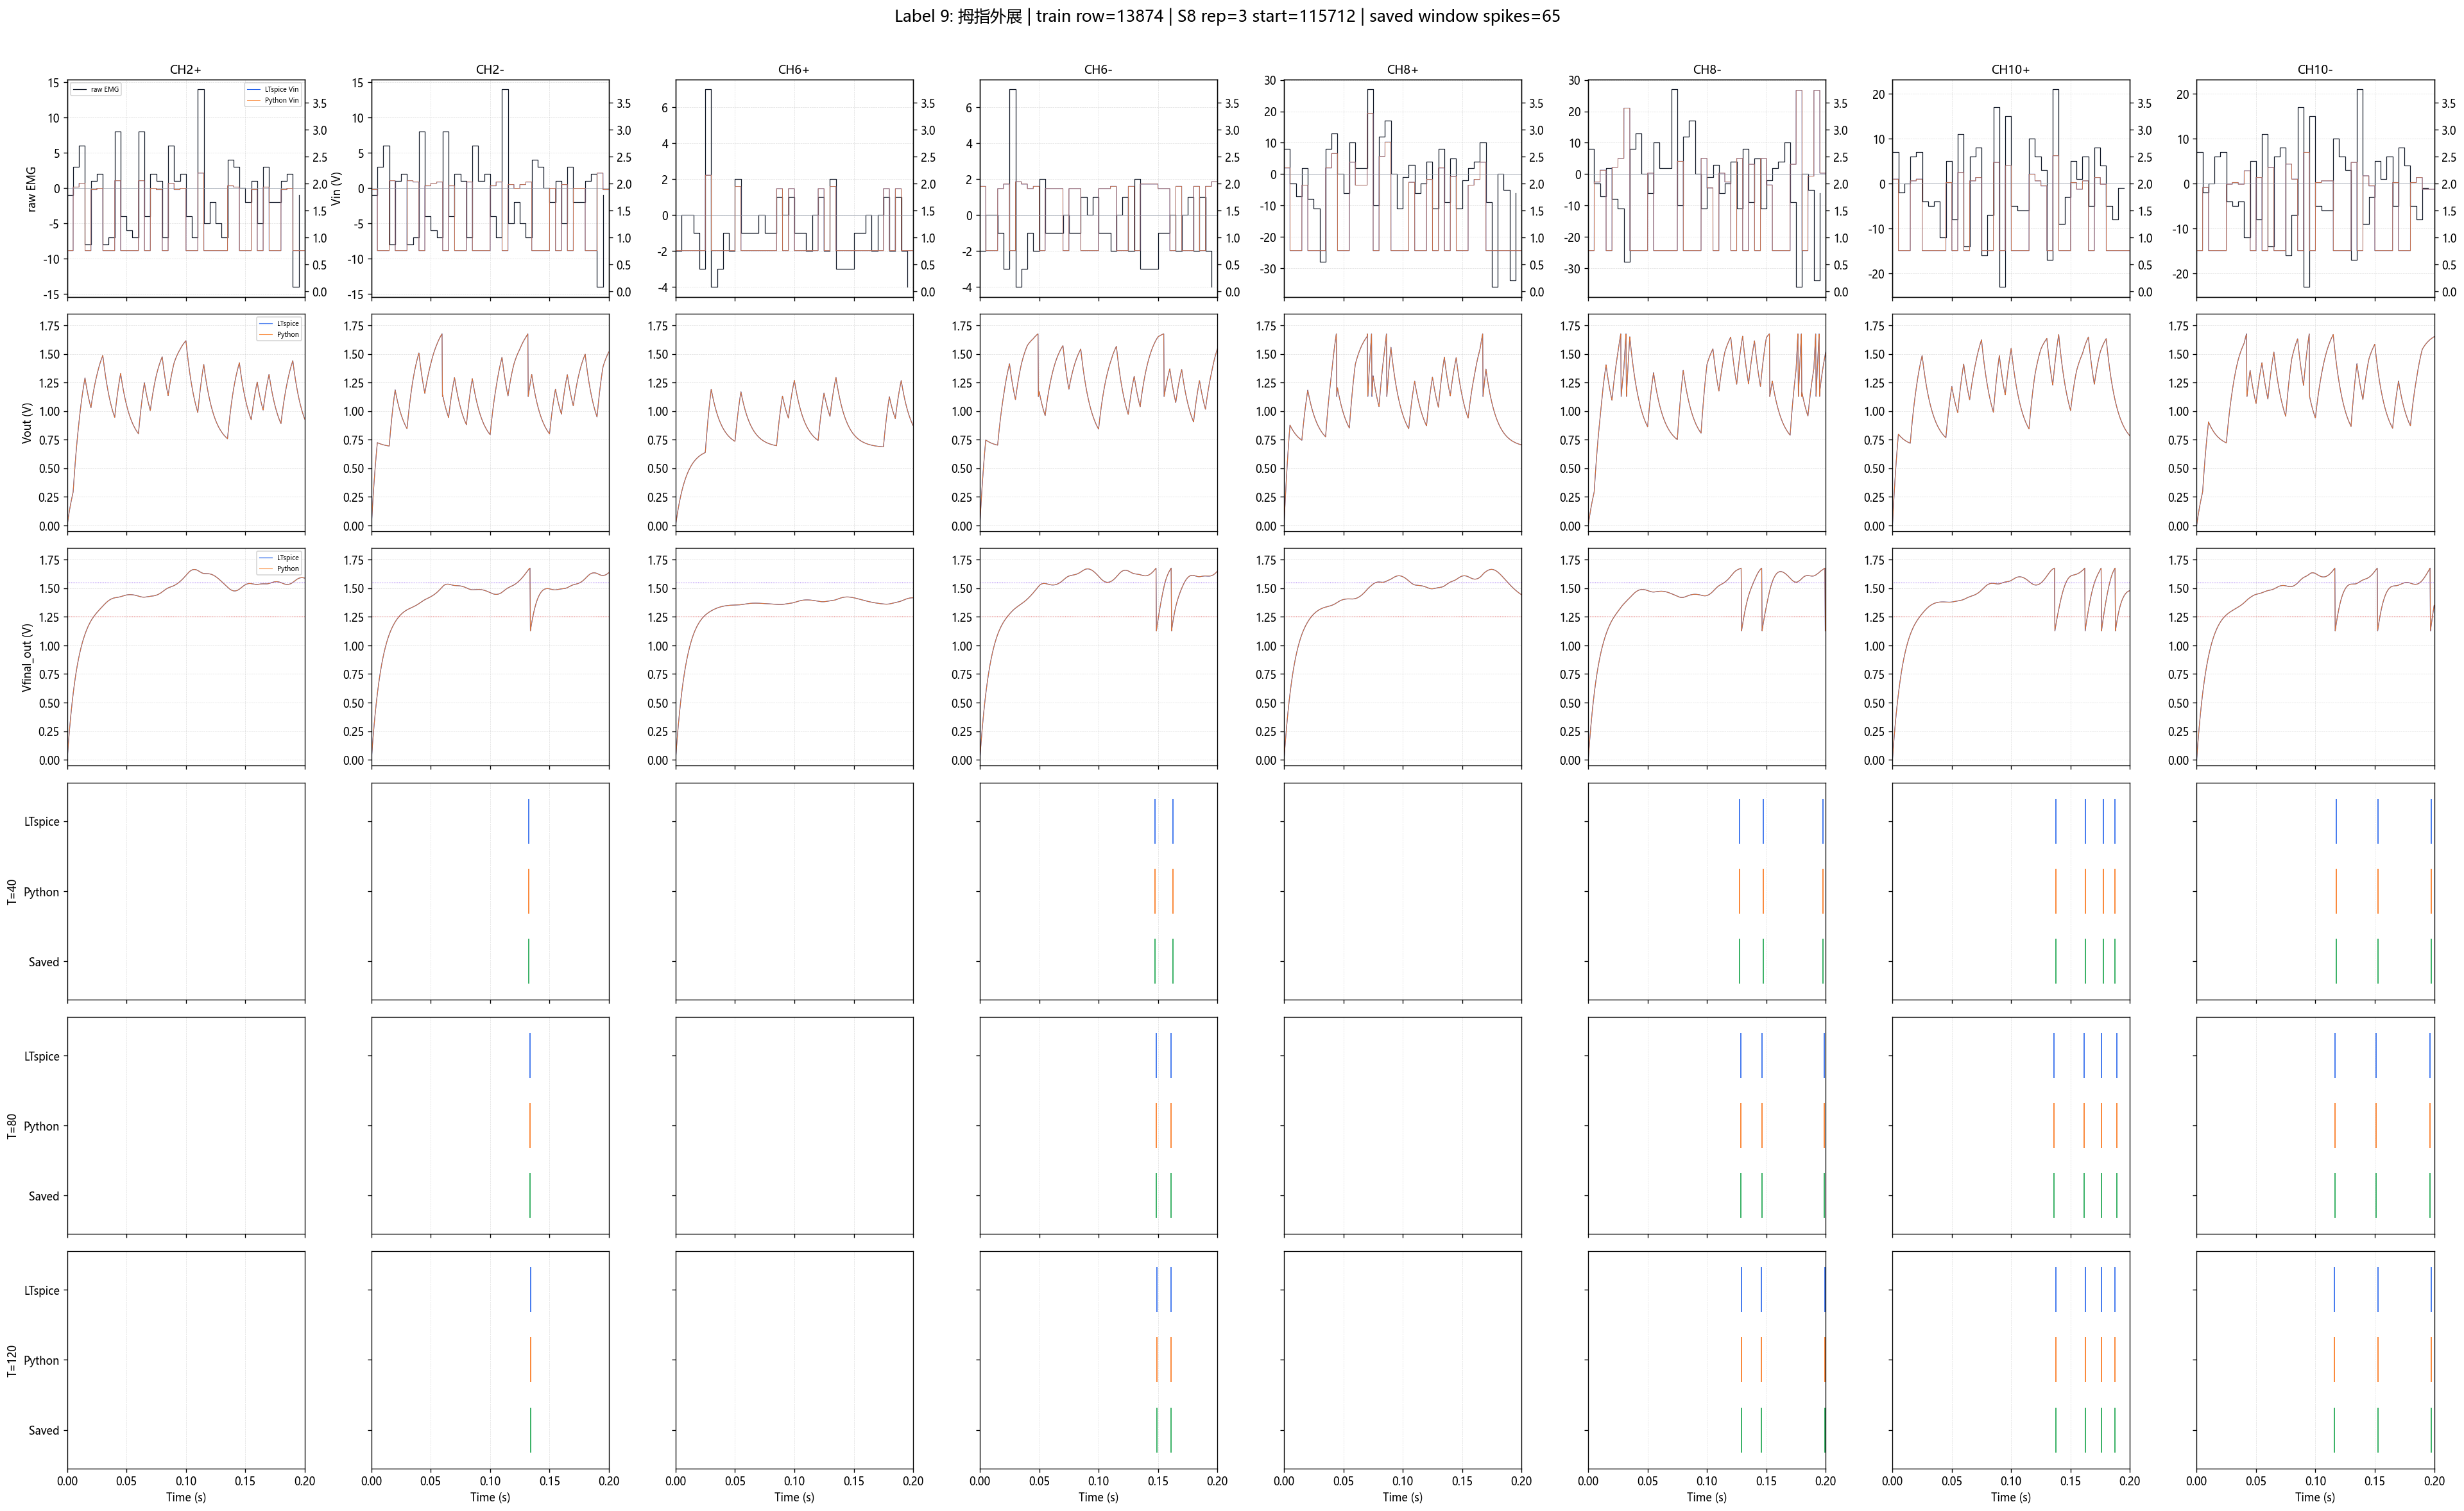

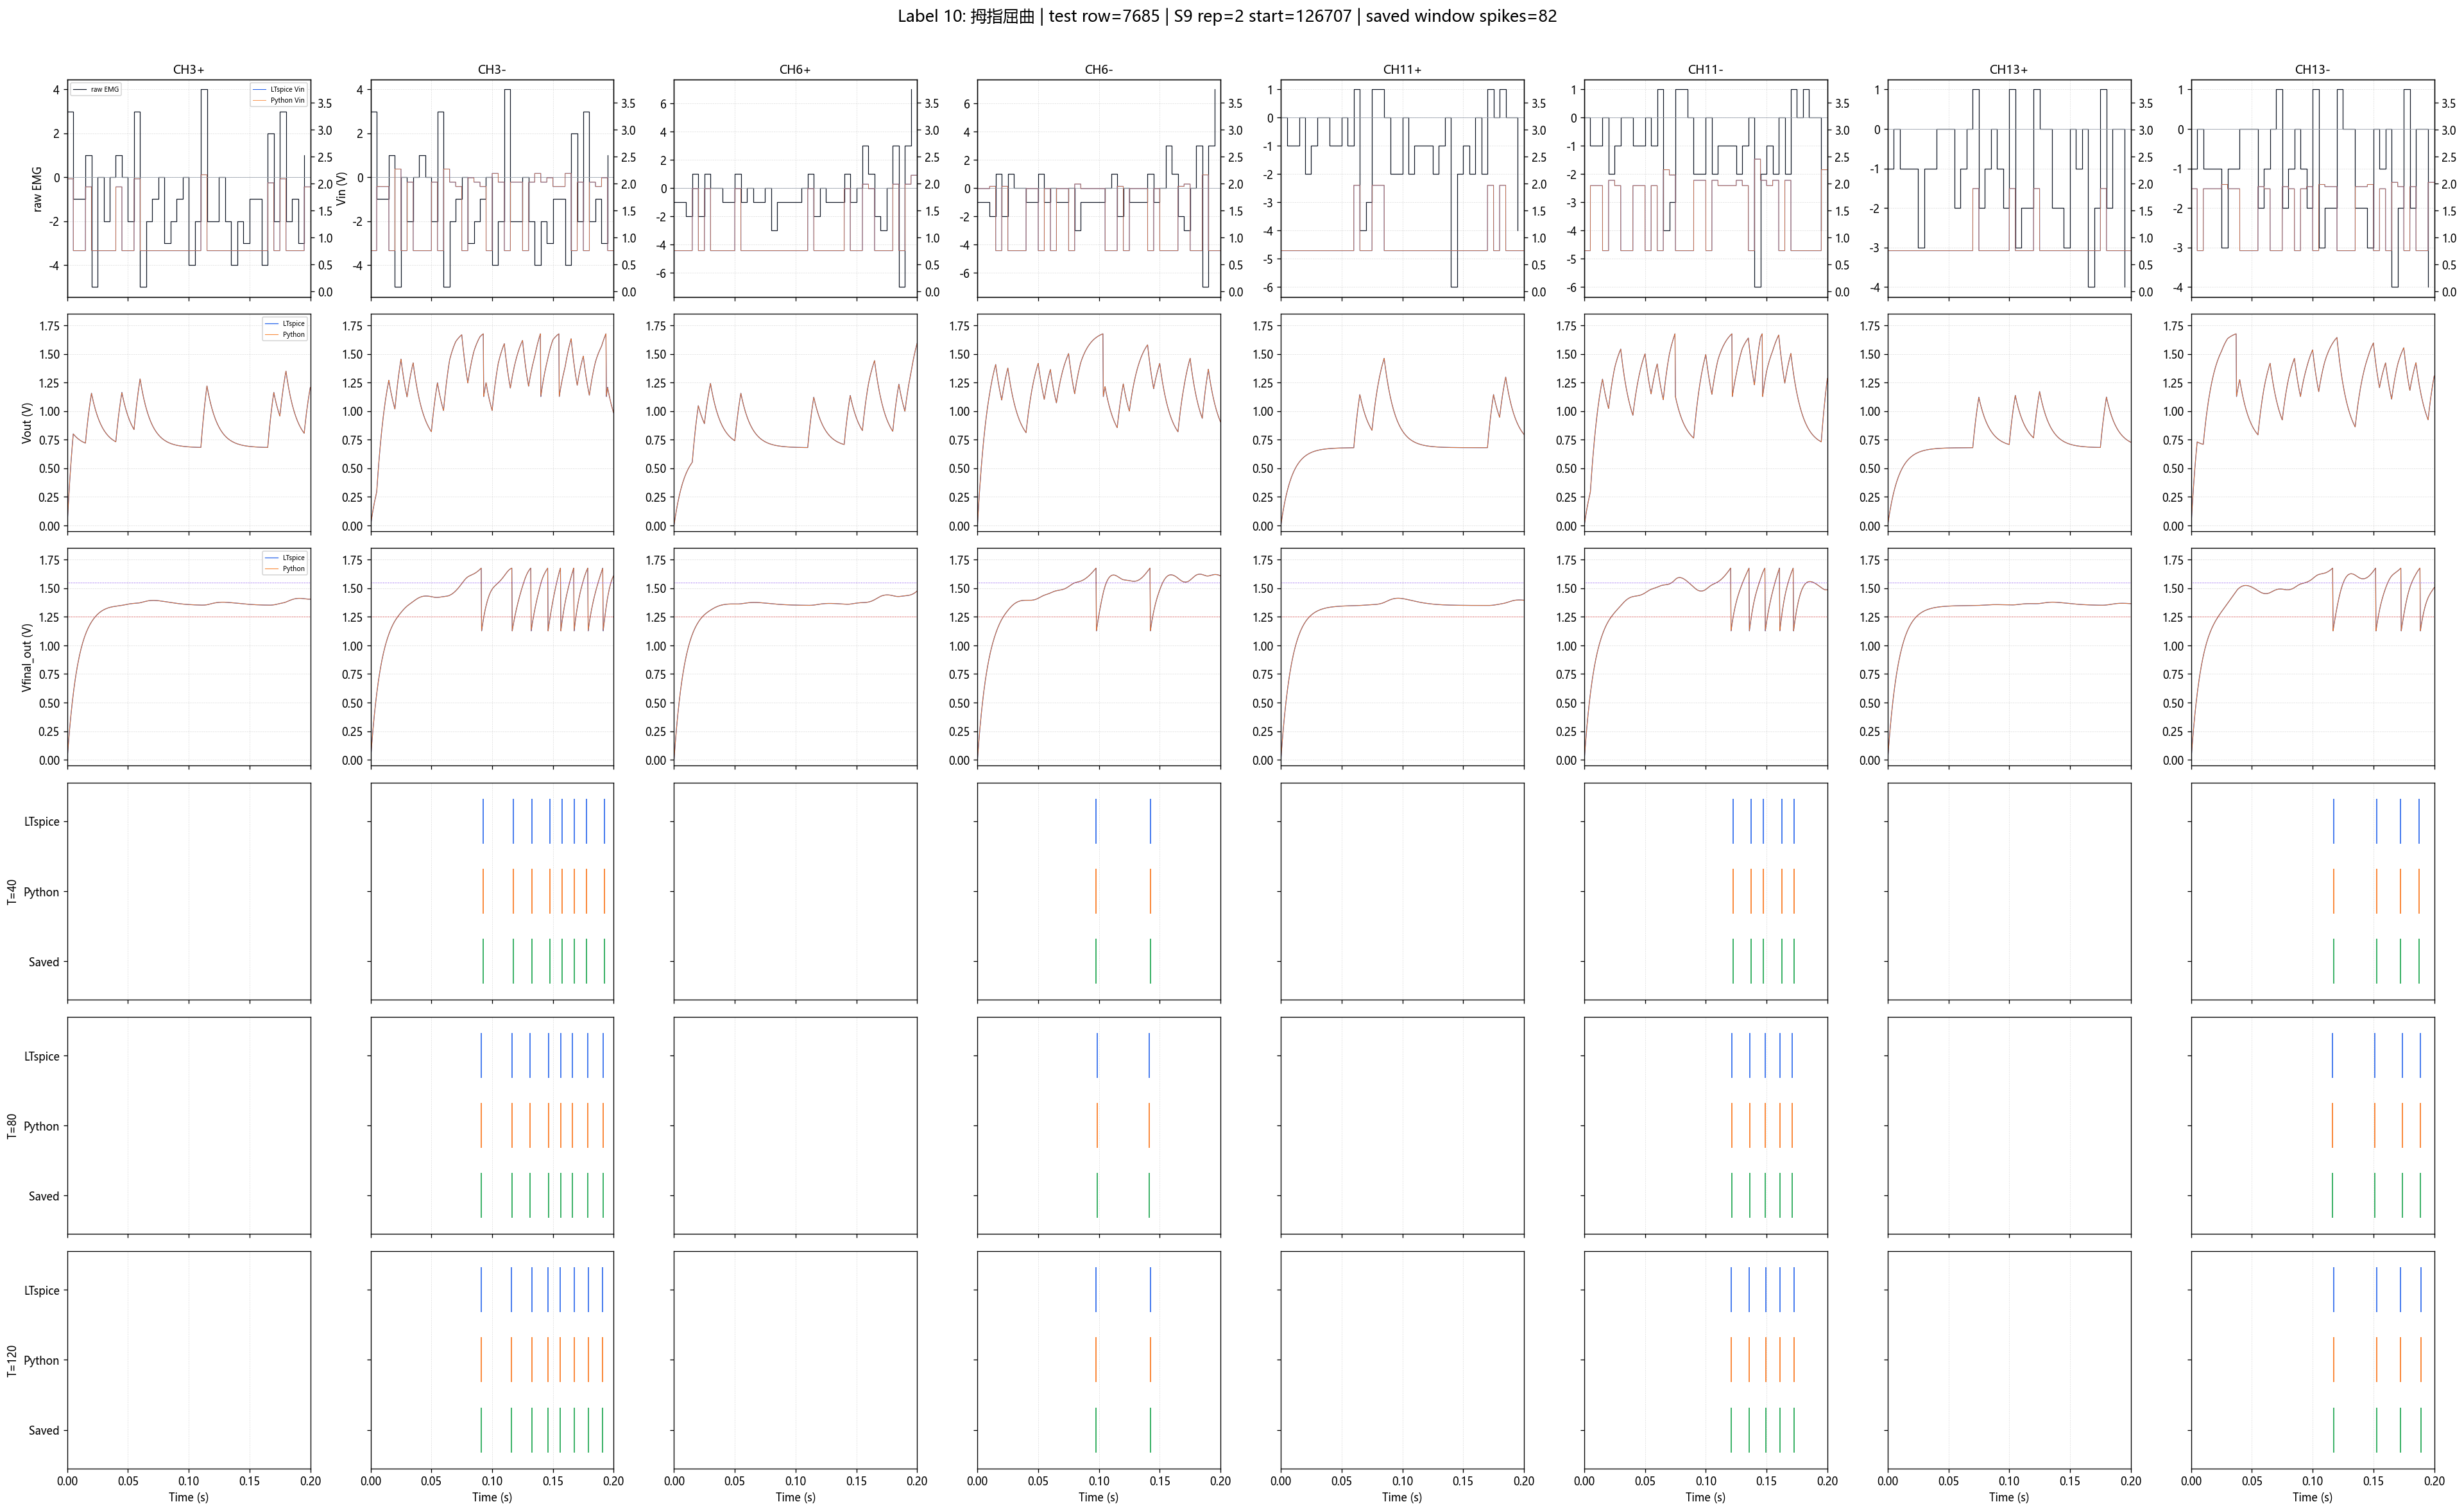

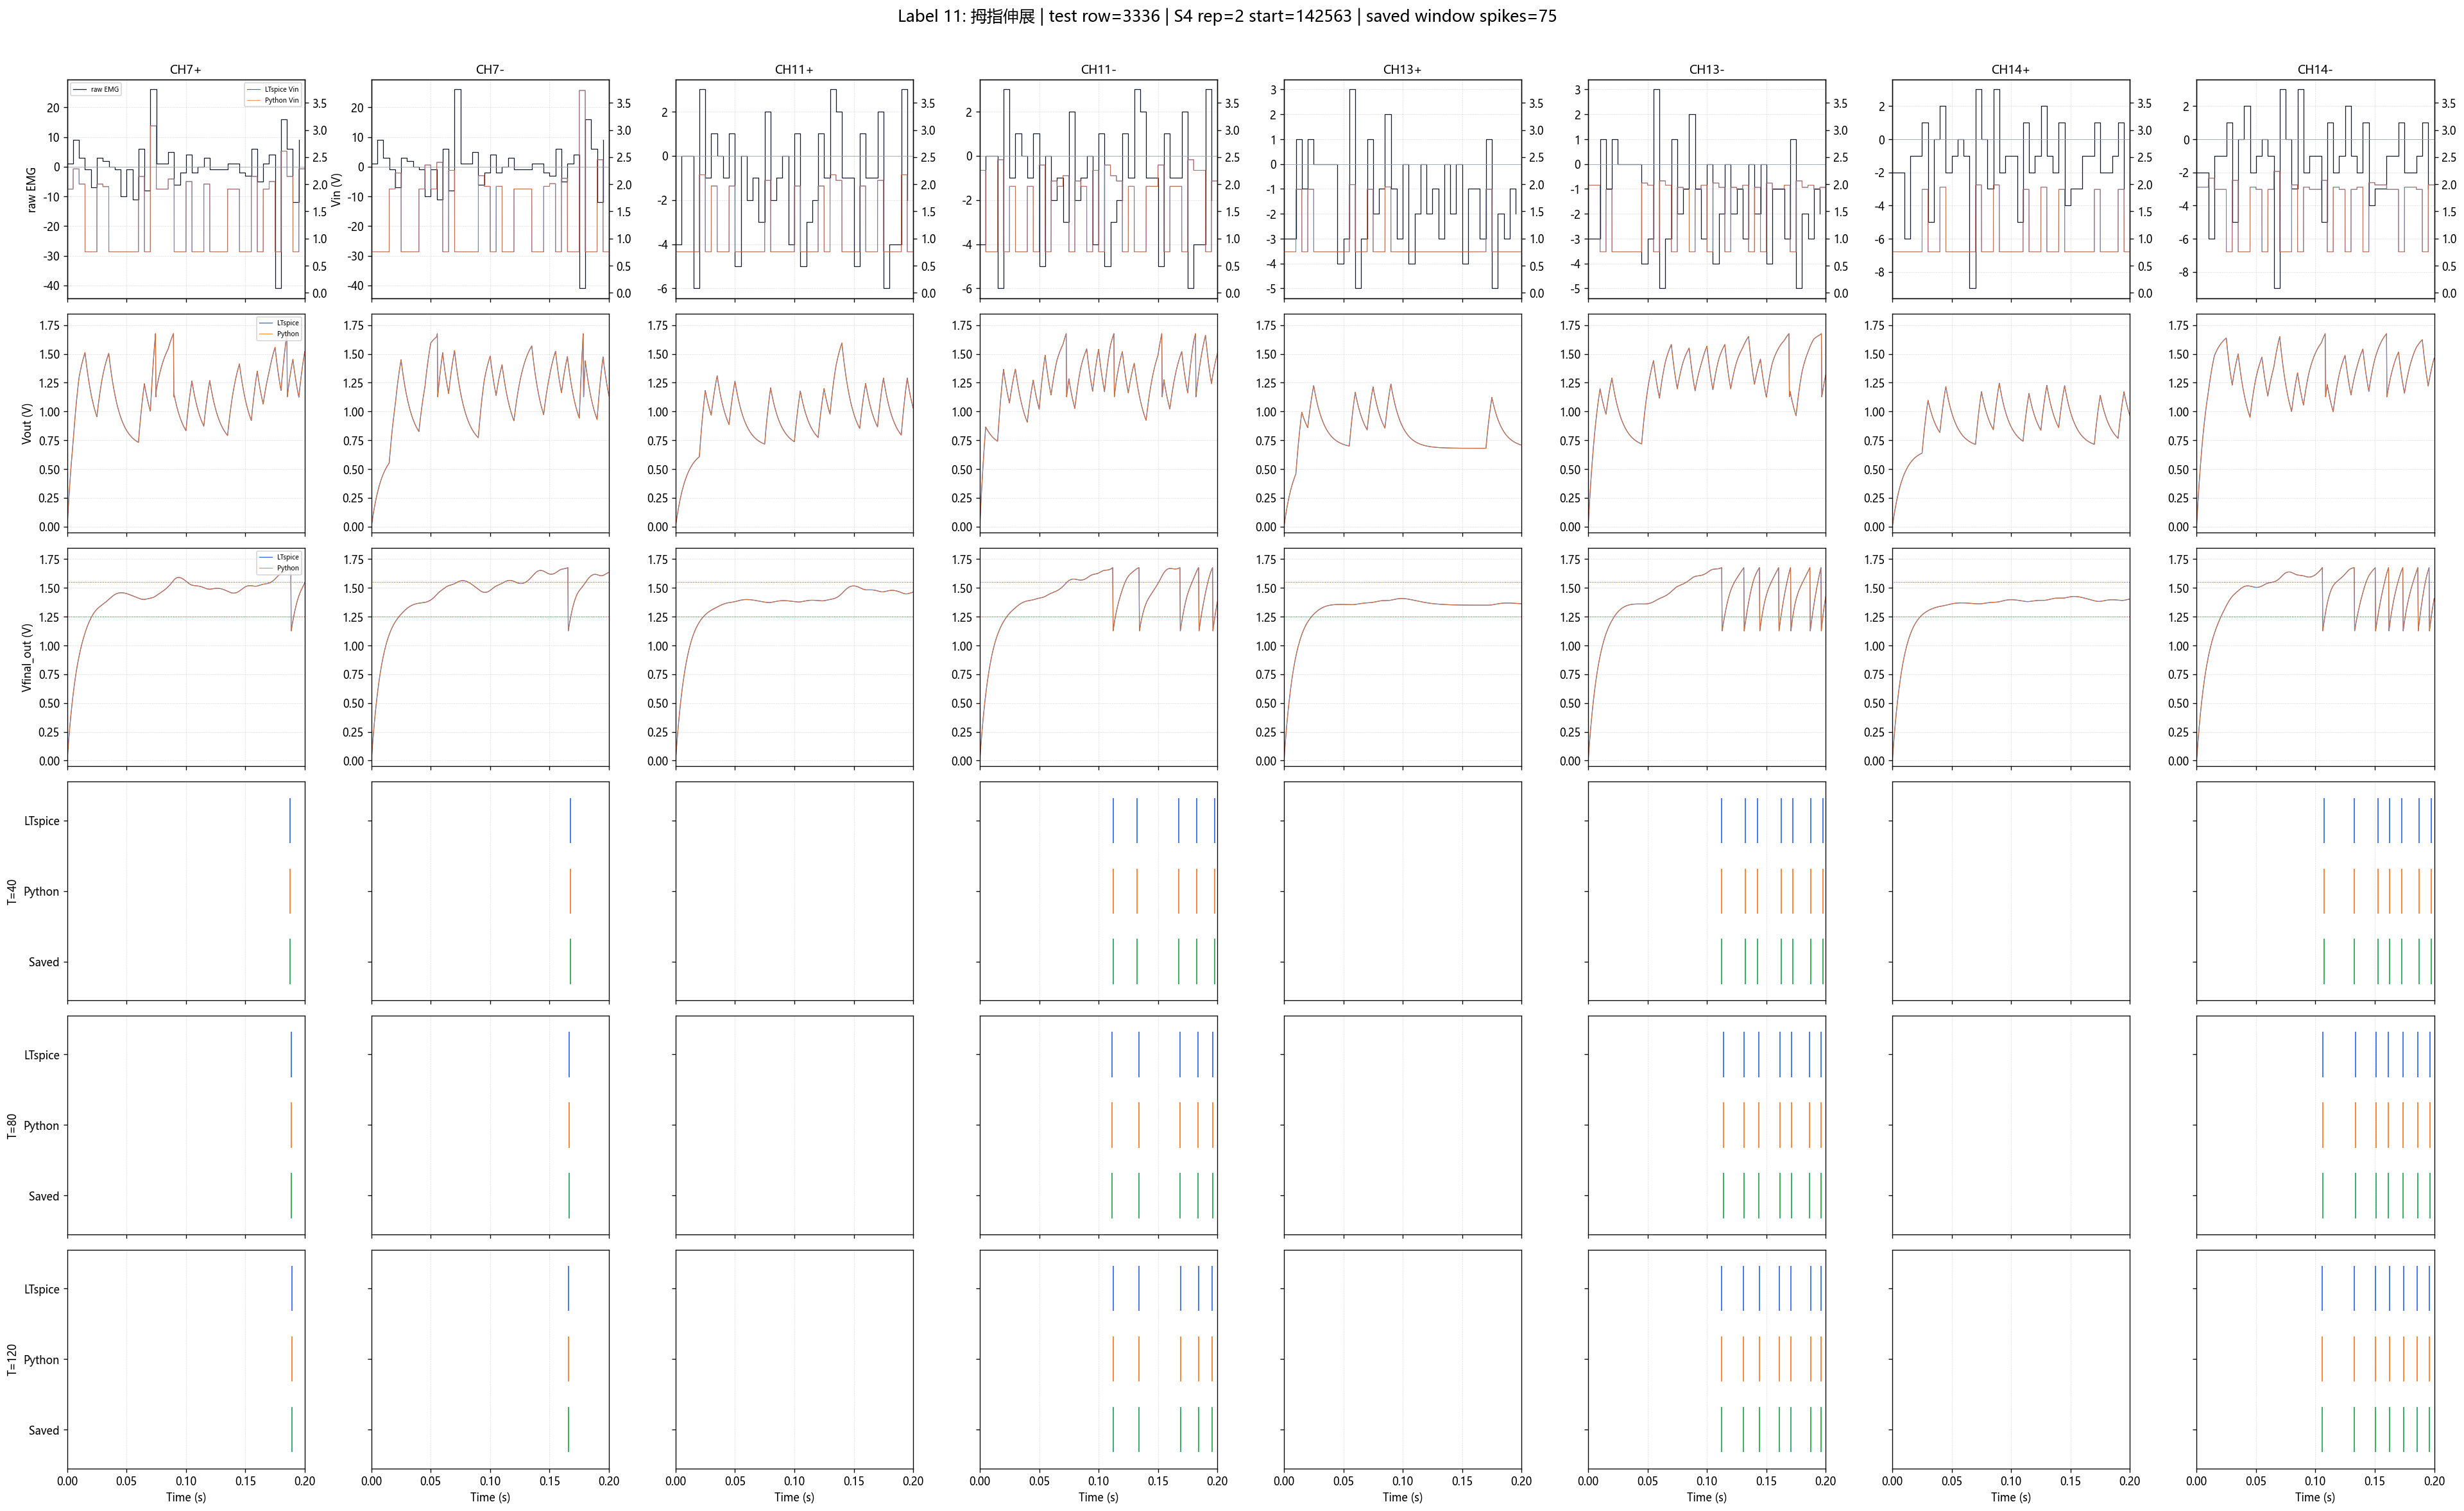

已生成12张动作综合对比图。


In [7]:
# 7. 为12个动作绘制原始EMG、正负Vin、波形与三种T三方脉冲
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

result_lookup = {
    (item["label"], item["original_channel"], item["polarity"]): item
    for item in simulation_results
}
sample_times = np.arange(WINDOW_SAMPLES, dtype=np.float64) / SAMPLE_RATE
action_figure_paths = []

for selection in selection_records:
    label = selection["label"]
    selected_channels = [
        int(value) + 1 for value in selection["selected_channel_indices"]
    ]
    columns = [
        (channel, polarity)
        for channel in selected_channels
        for polarity in ("positive", "negative")
    ]
    figure, axes = plt.subplots(
        6,
        len(columns),
        figsize=(32, 20),
        dpi=100,
        sharex="col",
    )

    for column, (channel, polarity) in enumerate(columns):
        result = result_lookup[(label, channel, polarity)]
        input_axis = axes[0, column]
        input_axis.step(
            sample_times,
            result["raw_sequence"],
            where="post",
            color="#111827",
            linewidth=0.75,
            label="raw EMG",
        )
        input_axis.axhline(0.0, color="#9ca3af", linewidth=0.5)
        vin_axis = input_axis.twinx()
        vin_axis.plot(
            result["lt_time"],
            result["lt_vin"],
            color="#2563eb",
            linewidth=0.65,
            label="LTspice Vin",
        )
        vin_axis.plot(
            result["py_time"],
            result["py_vin"],
            color="#f97316",
            linewidth=0.55,
            alpha=0.8,
            label="Python Vin",
        )
        vin_axis.set_ylim(-0.1, MAXIMUM_VOLTAGE + 0.2)
        input_axis.set_title(result["branch_name"], fontsize=11)
        input_axis.grid(True, linestyle="--", linewidth=0.4, alpha=0.45)

        axes[1, column].plot(
            result["lt_time"],
            result["lt_vout"],
            color="#2563eb",
            linewidth=0.75,
            label="LTspice",
        )
        axes[1, column].plot(
            result["py_time"],
            result["py_vout"],
            color="#f97316",
            linewidth=0.65,
            alpha=0.85,
            label="Python",
        )
        axes[1, column].set_ylim(-0.05, 1.85)
        axes[1, column].grid(
            True,
            linestyle="--",
            linewidth=0.4,
            alpha=0.45,
        )

        axes[2, column].plot(
            result["lt_time"],
            result["lt_final_out"],
            color="#2563eb",
            linewidth=0.75,
            label="LTspice",
        )
        axes[2, column].plot(
            result["py_time"],
            result["py_final_out"],
            color="#f97316",
            linewidth=0.65,
            alpha=0.85,
            label="Python",
        )
        axes[2, column].axhline(
            SPIKE_ARM,
            color="#7c3aed",
            linestyle=":",
            linewidth=0.6,
        )
        axes[2, column].axhline(
            SPIKE_FIRE,
            color="#dc2626",
            linestyle=":",
            linewidth=0.6,
        )
        axes[2, column].set_ylim(-0.05, 1.85)
        axes[2, column].grid(
            True,
            linestyle="--",
            linewidth=0.4,
            alpha=0.45,
        )

        for row_offset, T in enumerate(T_VALUES, start=3):
            binary_sets = result["binnings"][T]
            bin_duration = WINDOW_DURATION / T
            bin_centers = (
                np.arange(T, dtype=np.float64) + 0.5
            ) * bin_duration
            for row_value, key, color in (
                (2, "lt_binary", "#2563eb"),
                (1, "py_binary", "#f97316"),
                (0, "saved_binary", "#16a34a"),
            ):
                active_times = bin_centers[
                    np.flatnonzero(binary_sets[key])
                ]
                axes[row_offset, column].vlines(
                    active_times,
                    row_value - 0.32,
                    row_value + 0.32,
                    color=color,
                    linewidth=1.0,
                )
            axes[row_offset, column].set_yticks([0, 1, 2])
            axes[row_offset, column].set_yticklabels(
                ["Saved", "Python", "LTspice"]
                if column == 0
                else ["", "", ""]
            )
            axes[row_offset, column].set_ylim(-0.55, 2.55)
            axes[row_offset, column].set_xlim(0.0, WINDOW_DURATION)
            axes[row_offset, column].grid(
                True,
                axis="x",
                linestyle="--",
                linewidth=0.4,
                alpha=0.45,
            )

        if column == 0:
            input_axis.set_ylabel("raw EMG")
            vin_axis.set_ylabel("Vin (V)")
            axes[1, column].set_ylabel("Vout (V)")
            axes[2, column].set_ylabel("Vfinal_out (V)")
            for row_offset, T in enumerate(T_VALUES, start=3):
                axes[row_offset, column].set_ylabel(f"T={T}")
            input_axis.legend(loc="upper left", fontsize=6)
            vin_axis.legend(loc="upper right", fontsize=6)
            axes[1, column].legend(loc="upper right", fontsize=6)
            axes[2, column].legend(loc="upper right", fontsize=6)
        axes[-1, column].set_xlabel("Time (s)")

    figure.suptitle(
        f"Label {label}: {selection['action_name_zh']} | "
        f"{selection['split']} row={selection['row_index']} | "
        f"S{selection['subject']} rep={selection['repetition']} "
        f"start={selection['start_sample']} | "
        f"saved window spikes={selection['saved_window_spike_count']}",
        fontsize=15,
    )
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
    figure_path = (
        FIGURE_ROOT
        / f"label_{label:02d}_{selection['split']}_"
        f"row_{selection['row_index']:05d}.png"
    )
    figure.savefig(figure_path, dpi=120, bbox_inches="tight")
    plt.close(figure)
    action_figure_paths.append(figure_path)
    display(Image(filename=str(figure_path), width=1600))

print(f"已生成{len(action_figure_paths)}张动作综合对比图。")


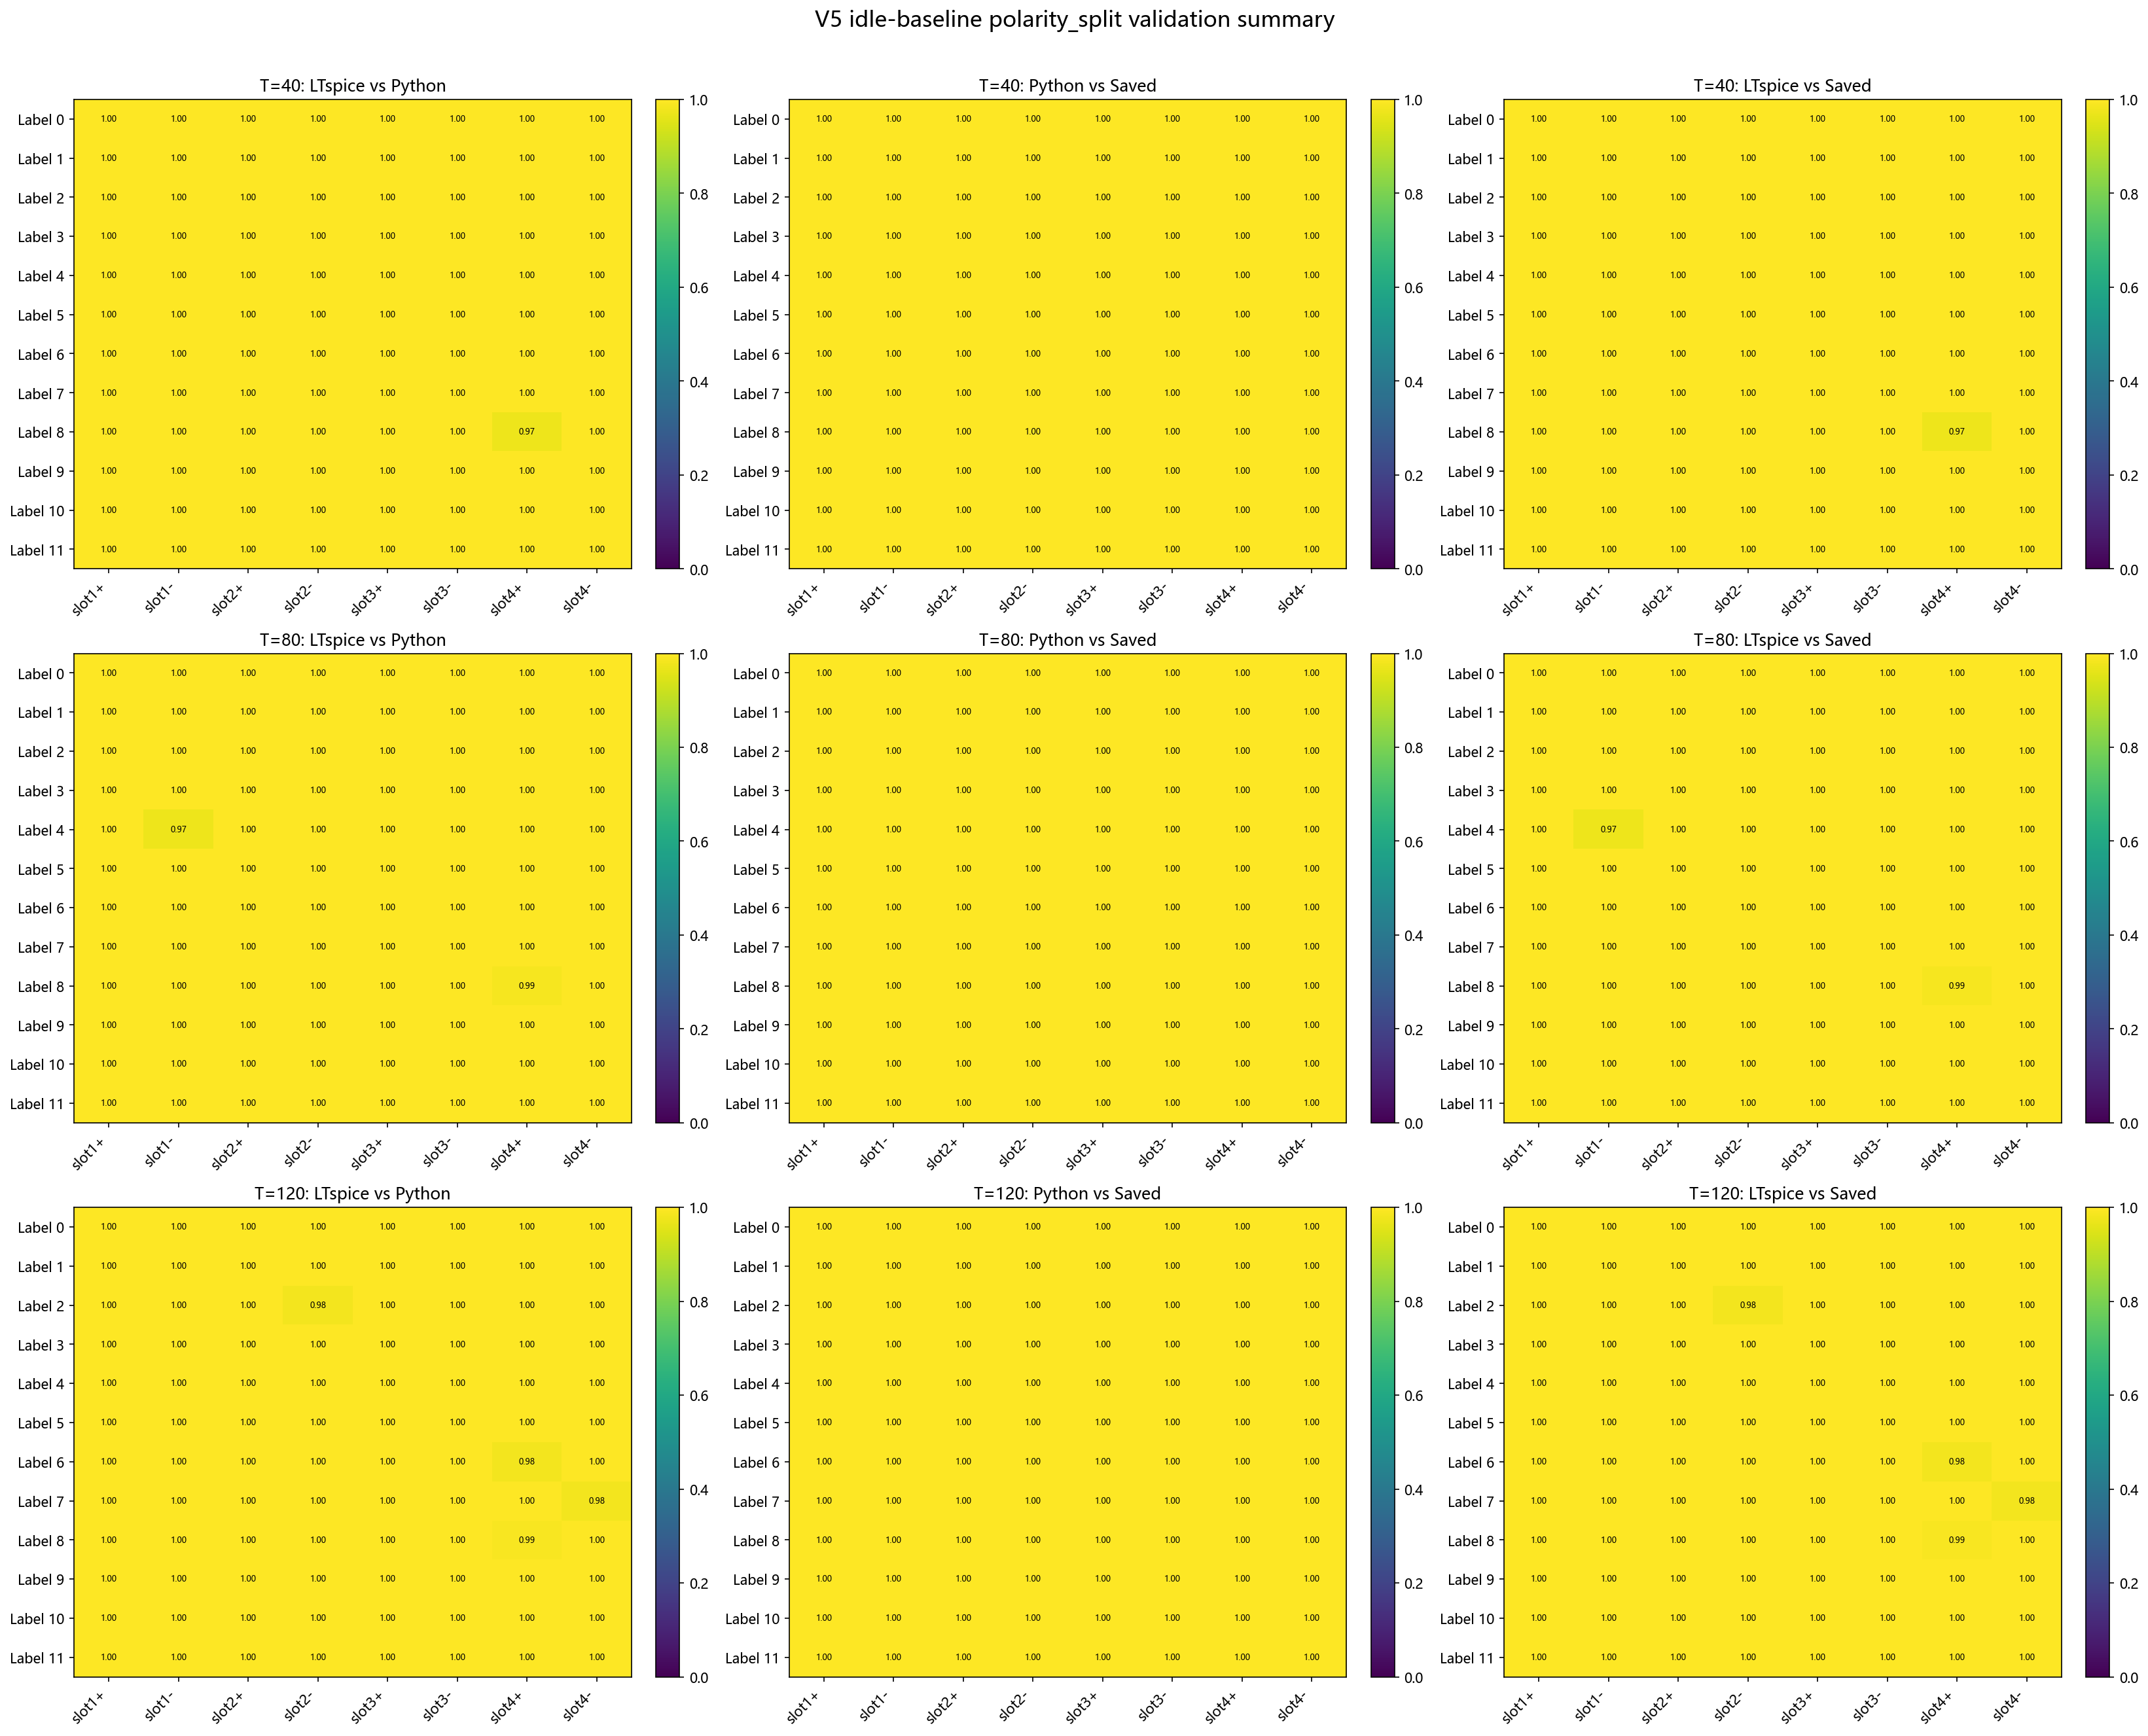

验证完成。
抽样清单：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\others\polarity_split_v5_spike_encoding_validation\selection_manifest.csv
逐分支指标：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\others\polarity_split_v5_spike_encoding_validation\validation_metrics.csv
汇总JSON：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\others\polarity_split_v5_spike_encoding_validation\validation_summary.json
动作图目录：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\others\polarity_split_v5_spike_encoding_validation\action_figures
汇总图：C:\Users\Fortyfour\Desktop\SNN_for_Ninapro\others\polarity_split_v5_spike_encoding_validation\validation_summary.png
硬性结论：所选96条正负分支在T=40、80、120下的Python二值脉冲和分箱计数均与保存数据逐元素一致。


In [8]:
# 8. 绘制三种T的总体一致率热图并给出最终结论
metric_lookup = {
    (
        item["T"],
        item["label"],
        item["original_channel"],
        item["polarity"],
    ): item
    for item in metrics
}
matrix_fields = (
    ("agreement_ltspice_python", "LTspice vs Python"),
    ("agreement_python_saved", "Python vs Saved"),
    ("agreement_ltspice_saved", "LTspice vs Saved"),
)

summary_figure, summary_axes = plt.subplots(
    len(T_VALUES),
    len(matrix_fields),
    figsize=(22, 18),
    dpi=110,
)
for row, T in enumerate(T_VALUES):
    for column, (field, title) in enumerate(matrix_fields):
        matrix = []
        for selection in selection_records:
            row_values = []
            for channel_index in selection["selected_channel_indices"]:
                channel = int(channel_index + 1)
                for polarity in ("positive", "negative"):
                    row_values.append(
                        metric_lookup[
                            (T, selection["label"], channel, polarity)
                        ][field]
                    )
            matrix.append(row_values)
        matrix = np.asarray(matrix, dtype=np.float64)
        axis = summary_axes[row, column]
        image = axis.imshow(
            matrix,
            aspect="auto",
            cmap="viridis",
            vmin=0.0,
            vmax=1.0,
        )
        for matrix_row in range(matrix.shape[0]):
            for matrix_column in range(matrix.shape[1]):
                axis.text(
                    matrix_column,
                    matrix_row,
                    f"{matrix[matrix_row, matrix_column]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=(
                        "white"
                        if matrix[matrix_row, matrix_column] < 0.5
                        else "black"
                    ),
                )
        axis.set_title(f"T={T}: {title}")
        axis.set_xticks(range(8))
        axis.set_xticklabels(
            [f"slot{i}{sign}" for i in range(1, 5) for sign in ("+", "-")],
            rotation=45,
            ha="right",
        )
        axis.set_yticks(range(12))
        axis.set_yticklabels([f"Label {label}" for label in range(12)])
        summary_figure.colorbar(
            image,
            ax=axis,
            fraction=0.046,
            pad=0.04,
        )

summary_figure.suptitle(
    "V5 idle-baseline polarity_split validation summary",
    fontsize=16,
)
summary_figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
summary_figure_path = RESULT_ROOT / "validation_summary.png"
summary_figure.savefig(
    summary_figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.close(summary_figure)
display(Image(filename=str(summary_figure_path), width=1500))

print("验证完成。")
print(f"抽样清单：{selection_manifest_path}")
print(f"逐分支指标：{metrics_path}")
print(f"汇总JSON：{summary_path}")
print(f"动作图目录：{FIGURE_ROOT}")
print(f"汇总图：{summary_figure_path}")
print(
    "硬性结论：所选96条正负分支在T=40、80、120下的Python"
    "二值脉冲和分箱计数均与保存数据逐元素一致。"
)
